# Bronze | Importação da Base Inicial

Instalação de funções

In [4]:
%worker_type G.1X
%number_of_workers 2
%idle_timeout 15

Welcome to the Glue Interactive Sessions Kernel
For more information on available magic commands, please type %help in any new cell.

Please view our Getting Started page to access the most up-to-date information on the Interactive Sessions kernel: https://docs.aws.amazon.com/glue/latest/dg/interactive-sessions.html
Installed kernel version: 1.0.10 
Previous worker type: None
Setting new worker type to: G.1X
Previous number of workers: None
Setting new number of workers to: 2
Current idle_timeout is None minutes.
idle_timeout has been set to 15 minutes.


In [6]:
%extra_py_files s3://lab-802081848218/scripts/Funcoes_Fase3.py

Extra py files to be included:
s3://lab-802081848218/scripts/Funcoes_Fase3.py


In [8]:
%pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 208.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 223.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 131.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 172.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [matplotlib]8 [matplotlib]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /usr/local/bin/.pyenv/versions/3.9.9/bin/python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
from pyspark.sql.functions import input_file_name
from pyspark.sql.functions import regexp_extract
import pandas as pd
import matplotlib.pyplot as plt


from Funcoes_Fase3 import limpar_nome_coluna, verificar_nulos
from pyspark.sql.window import Window


Trying to create a Glue session for the kernel.
Session Type: glueetl
Worker Type: G.1X
Number of Workers: 2
Idle Timeout: 15
Session ID: f648190e-32dd-4f80-93c5-fb11aa8f53d7
Applying the following default arguments:
--glue_kernel_version 1.0.10
--enable-glue-datacatalog true
--extra-py-files s3://lab-802081848218/scripts/Funcoes_Fase3.py
Waiting for session f648190e-32dd-4f80-93c5-fb11aa8f53d7 to get into ready status...
Session f648190e-32dd-4f80-93c5-fb11aa8f53d7 has been created.



Iniciando a sessão

In [2]:
spark = SparkSession.builder.getOrCreate()

Versão utilizada

In [3]:
print(spark.version)

3.3.0-amzn-1


In [4]:
spark.sql("SHOW TABLES IN fiap_grupo_62").show(truncate=False)

+-------------+----------+-----------+
|namespace    |tableName |isTemporary|
+-------------+----------+-----------+
|fiap_grupo_62|tb_2023_24|false      |
|fiap_grupo_62|tb_2024_25|false      |
|fiap_grupo_62|tb_2025_26|false      |
+-------------+----------+-----------+


Separando as tabelas

In [5]:
df_2023_24 = spark.table("fiap_grupo_62.tb_2023_24")
df_2024_25 = spark.table("fiap_grupo_62.tb_2024_25")
df_2025_26 = spark.table("fiap_grupo_62.tb_2025_26")

# Silver | Exploração e Tratamentos

Estudo das bases

In [6]:
print("2023/24 | Quantidade de linhas:", df_2023_24.count(), "Quantidade de colunas:" , len(df_2023_24.columns))
print("2024/25 | Quantidade de linhas:", df_2024_25.count(), "Quantidade de colunas:" , len(df_2024_25.columns))
print("2025/26 | Quantidade de linhas:", df_2025_26.count(), "Quantidade de colunas:" , len(df_2025_26.columns))

2023/24 | Quantidade de linhas: 5293 Quantidade de colunas: 399
2024/25 | Quantidade de linhas: 5217 Quantidade de colunas: 403
2025/26 | Quantidade de linhas: 3495 Quantidade de colunas: 388


In [7]:
df_2023_24.printSchema()

root
 |-- _'p0'__'id'_#0: string (nullable = true)
 |-- _'p1_a_'__'idade'_#1: string (nullable = true)
 |-- _'p1_a_1_'__'faixa_idade'_#2: string (nullable = true)
 |-- _'p1_b_'__'genero'_#3: string (nullable = true)
 |-- _'p1_c_'__'cor/raca/etnia'_#4: string (nullable = true)
 |-- _'p1_d_'__'pcd'_#5: string (nullable = true)
 |-- _'p1_e_'__'experiencia_profissional_prejudicada'_#6: string (nullable = true)
 |-- _'p1_e_1_'__'não_acredito_que_minha_experiência_profissional_seja_afetada'_#7: string (nullable = true)
 |-- _'p1_e_2_'__'experiencia_prejudicada_devido_a_minha_cor_raça_etnia'_#8: string (nullable = true)
 |-- _'p1_e_3_'__'experiencia_prejudicada_devido_a_minha_identidade_de_gênero'_#9: string (nullable = true)
 |-- _'p1_e_4_'__'experiencia_prejudicada_devido_ao_fato_de_ser_pcd'_#10: string (nullable = true)
 |-- _'p1_f_'__'aspectos_prejudicados'_#11: string (nullable = true)
 |-- _'p1_f_1'__'quantidade_de_oportunidades_de_emprego/vagas_recebidas'_#12: string (nullable = true)


In [8]:
df_2024_25.printSchema()

root
 |-- 0.a_token: string (nullable = true)
 |-- 0.d_data/hora_envio: string (nullable = true)
 |-- 1.a_idade: string (nullable = true)
 |-- 1.a.1_faixa_idade: string (nullable = true)
 |-- 1.b_genero: string (nullable = true)
 |-- 1.c_cor/raca/etnia: string (nullable = true)
 |-- 1.d_pcd: string (nullable = true)
 |-- 1.e_experiencia_profissional_prejudicada: string (nullable = true)
 |-- 1.e.1_não_acredito_que_minha_experiência_profissional_seja_afetada#0: string (nullable = true)
 |-- 1.e.2_sim__devido_a_minha_cor/raça/etnia#1: string (nullable = true)
 |-- 1.e.3_sim__devido_a_minha_identidade_de_gênero#2: string (nullable = true)
 |-- 1.e.4_sim__devido_ao_fato_de_ser_pcd#3: string (nullable = true)
 |-- 1.i.1_uf_onde_mora: string (nullable = true)
 |-- 1.f.1_quantidade_de_oportunidades_de_emprego/vagas_recebidas#4: string (nullable = true)
 |-- 1.f.2_senioridade_das_vagas_recebidas_em_relação_à_sua_experiência#5: string (nullable = true)
 |-- 1.f.3_aprovação_em_processos_seletivo

In [9]:
df_2025_26.printSchema()

root
 |-- 0.a_token: string (nullable = true)
 |-- 0.d_data/hora_envio: string (nullable = true)
 |-- 1.a_idade: string (nullable = true)
 |-- 1.a.1_faixa_idade: string (nullable = true)
 |-- 1.b_genero: string (nullable = true)
 |-- 1.c_cor/raca/etnia: string (nullable = true)
 |-- 1.d_pcd: string (nullable = true)
 |-- 1.e_experiencia_profissional_prejudicada: string (nullable = true)
 |-- 1.e.1_não_acredito_que_minha_experiência_profissional_seja_afetada#0: string (nullable = true)
 |-- 1.e.2_sim__devido_a_minha_cor/raça/etnia#1: string (nullable = true)
 |-- 1.e.3_sim__devido_a_minha_identidade_de_gênero#2: string (nullable = true)
 |-- 1.e.4_sim__devido_ao_fato_de_ser_pcd#3: string (nullable = true)
 |-- 1.f_aspectos_prejudicados: string (nullable = true)
 |-- 1.f.1_quantidade_de_oportunidades_de_emprego/vagas_recebidas#4: string (nullable = true)
 |-- 1.f.2_senioridade_das_vagas_recebidas_em_relação_à_sua_experiência#5: string (nullable = true)
 |-- 1.f.3_aprovação_em_processos_s

Apagando duplicidades

In [10]:
total = df_2023_24.count()
unicos = df_2023_24.dropDuplicates().count()

print(f"Total: {total}")
print(f"Únicos: {unicos}")
print(f"Duplicados: {total - unicos}")
print(f"Unicidade: {(unicos / total) * 100:.2f}%")

Total: 5293
Únicos: 5293
Duplicados: 0
Unicidade: 100.00%


In [11]:
total = df_2024_25.count()
unicos = df_2024_25.dropDuplicates().count()

print(f"Total: {total}")
print(f"Únicos: {unicos}")
print(f"Duplicados: {total - unicos}")
print(f"Unicidade: {(unicos / total) * 100:.2f}%")

Total: 5217
Únicos: 5215
Duplicados: 2
Unicidade: 99.96%


In [12]:
df_2024_25 = df_2024_25.dropDuplicates()

In [13]:
total = df_2024_25.count()
unicos = df_2024_25.dropDuplicates().count()

print(f"Duplicados apagados da base 2024/25, unicidade: {(unicos / total) * 100:.2f}%")

Duplicados apagados da base 2024/25, unicidade: 100.00%


In [14]:
total = df_2025_26.count()
unicos = df_2025_26.dropDuplicates().count()

print(f"Total: {total}")
print(f"Únicos: {unicos}")
print(f"Duplicados: {total - unicos}")
print(f"Unicidade: {(unicos / total) * 100:.2f}%")

Total: 3495
Únicos: 3494
Duplicados: 1
Unicidade: 99.97%


In [15]:
df_2025_26 = df_2025_26.dropDuplicates()

In [16]:
total = df_2025_26.count()
unicos = df_2025_26.dropDuplicates().count()

print(f"Duplicados apagados da base 2025/26, unicidade: {(unicos / total) * 100:.2f}%")

Duplicados apagados da base 2025/26, unicidade: 100.00%


Aplica a função para limpeza das colunas, remove aspas, espaços e outras caracteristicas

In [17]:
df_2023_24 = df_2023_24.toDF(
    *[limpar_nome_coluna(c) for c in df_2023_24.columns]
)

In [18]:
df_2024_25 = df_2024_25.toDF(
    *[limpar_nome_coluna(c) for c in df_2024_25.columns]
)

In [19]:
df_2025_26 = df_2025_26.toDF(
    *[limpar_nome_coluna(c) for c in df_2025_26.columns]
)

Tranforma vazios em nulos e remove espaços desnecessarios

In [20]:
df_2023_24 = df_2023_24.select([
    F.when(F.trim(F.col(c)) == "", None)
     .otherwise(F.trim(F.col(c)))
     .alias(c)
    for c in df_2023_24.columns
])

df_2024_25 = df_2024_25.select([
    F.when(F.trim(F.col(c)) == "", None)
     .otherwise(F.trim(F.col(c)))
     .alias(c)
    for c in df_2024_25.columns
])

df_2025_26 = df_2025_26.select([
    F.when(F.trim(F.col(c)) == "", None)
     .otherwise(F.trim(F.col(c)))
     .alias(c)
    for c in df_2025_26.columns
])

In [21]:
nulos_2023 = verificar_nulos(df_2023_24,spark)

In [22]:
nulos_2024 = verificar_nulos(df_2024_25,spark)

In [23]:
nulos_2025 = verificar_nulos(df_2025_26,spark)

Validação de colunas nulas e possiveis inconsistencias

In [24]:
nulos_2023.orderBy(
    F.col("percentual_nulos").desc()
).show(20, truncate=False)

+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------+---------------+----------------+
|coluna                                                                                                                                                                                              |qtd_nulos|qtd_preenchidos|percentual_nulos|
+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------+---------------+----------------+
|p5_d_como_tem_sido_a_busca_por_um_emprego_na_area_de_dados_247                                                                                                                                      |5007     |286            |94.6            |
|p5_c_ha_quanto_tempo_voce_busca

In [25]:
nulos_2024.orderBy(
    F.col("percentual_nulos").desc()
).show(20, truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------+---------------+----------------+
|coluna                                                                                                                                                                                             |qtd_nulos|qtd_preenchidos|percentual_nulos|
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------+---------------+----------------+
|1_h_pais_onde_mora                                                                                                                                                                                 |5076     |139            |97.33           |
|5_b_oportunidade_buscada           

In [26]:
nulos_2025.orderBy(
    F.col("percentual_nulos").desc()
).show(20, truncate=False)

+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------+---------------+----------------+
|coluna                                                                                                                                                                                             |qtd_nulos|qtd_preenchidos|percentual_nulos|
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+---------+---------------+----------------+
|1_h_pais_onde_mora                                                                                                                                                                                 |3372     |122            |96.51           |
|5_b_oportunidade_buscada           

Obs: Foram aceitadas a concentração de valores nulos em algumas colunas, esperado pois algumas perguntas são condicionadas as respostas anteriores do questionário.

Nomenclatura final - Camada Silver

In [27]:
df_2023_24.printSchema()

root
 |-- p0_id_0: string (nullable = true)
 |-- p1_a_idade_1: string (nullable = true)
 |-- p1_a_1_faixa_idade_2: string (nullable = true)
 |-- p1_b_genero_3: string (nullable = true)
 |-- p1_c_cor_raca_etnia_4: string (nullable = true)
 |-- p1_d_pcd_5: string (nullable = true)
 |-- p1_e_experiencia_profissional_prejudicada_6: string (nullable = true)
 |-- p1_e_1_nao_acredito_que_minha_experiencia_profissional_seja_afetada_7: string (nullable = true)
 |-- p1_e_2_experiencia_prejudicada_devido_a_minha_cor_raca_etnia_8: string (nullable = true)
 |-- p1_e_3_experiencia_prejudicada_devido_a_minha_identidade_de_genero_9: string (nullable = true)
 |-- p1_e_4_experiencia_prejudicada_devido_ao_fato_de_ser_pcd_10: string (nullable = true)
 |-- p1_f_aspectos_prejudicados_11: string (nullable = true)
 |-- p1_f_1_quantidade_de_oportunidades_de_emprego_vagas_recebidas_12: string (nullable = true)
 |-- p1_f_2_senioridade_das_vagas_recebidas_em_relacao_a_sua_experiencia_13: string (nullable = true)


In [28]:
df_2024_25.printSchema()

root
 |-- 0_a_token: string (nullable = true)
 |-- 0_d_data_hora_envio: string (nullable = true)
 |-- 1_a_idade: string (nullable = true)
 |-- 1_a_1_faixa_idade: string (nullable = true)
 |-- 1_b_genero: string (nullable = true)
 |-- 1_c_cor_raca_etnia: string (nullable = true)
 |-- 1_d_pcd: string (nullable = true)
 |-- 1_e_experiencia_profissional_prejudicada: string (nullable = true)
 |-- 1_e_1_nao_acredito_que_minha_experiencia_profissional_seja_afetada_0: string (nullable = true)
 |-- 1_e_2_sim_devido_a_minha_cor_raca_etnia_1: string (nullable = true)
 |-- 1_e_3_sim_devido_a_minha_identidade_de_genero_2: string (nullable = true)
 |-- 1_e_4_sim_devido_ao_fato_de_ser_pcd_3: string (nullable = true)
 |-- 1_i_1_uf_onde_mora: string (nullable = true)
 |-- 1_f_1_quantidade_de_oportunidades_de_emprego_vagas_recebidas_4: string (nullable = true)
 |-- 1_f_2_senioridade_das_vagas_recebidas_em_relacao_a_sua_experiencia_5: string (nullable = true)
 |-- 1_f_3_aprovacao_em_processos_seletivos_e

In [29]:
df_2025_26.printSchema()

root
 |-- 0_a_token: string (nullable = true)
 |-- 0_d_data_hora_envio: string (nullable = true)
 |-- 1_a_idade: string (nullable = true)
 |-- 1_a_1_faixa_idade: string (nullable = true)
 |-- 1_b_genero: string (nullable = true)
 |-- 1_c_cor_raca_etnia: string (nullable = true)
 |-- 1_d_pcd: string (nullable = true)
 |-- 1_e_experiencia_profissional_prejudicada: string (nullable = true)
 |-- 1_e_1_nao_acredito_que_minha_experiencia_profissional_seja_afetada_0: string (nullable = true)
 |-- 1_e_2_sim_devido_a_minha_cor_raca_etnia_1: string (nullable = true)
 |-- 1_e_3_sim_devido_a_minha_identidade_de_genero_2: string (nullable = true)
 |-- 1_e_4_sim_devido_ao_fato_de_ser_pcd_3: string (nullable = true)
 |-- 1_f_aspectos_prejudicados: string (nullable = true)
 |-- 1_f_1_quantidade_de_oportunidades_de_emprego_vagas_recebidas_4: string (nullable = true)
 |-- 1_f_2_senioridade_das_vagas_recebidas_em_relacao_a_sua_experiencia_5: string (nullable = true)
 |-- 1_f_3_aprovacao_em_processos_sele

In [30]:
df_silver_2023_24 = df_2023_24
df_silver_2024_25 = df_2024_25
df_silver_2025_26 = df_2025_26

# Gold | Preparação Analítica

In [31]:
perfil_2023_24 = df_silver_2023_24.select(
    F.col("p0_id_0").alias("id"),
    F.col("p1_a_1_faixa_idade_2").alias("faixa_idade"),
    F.col("p1_b_genero_3").alias("genero"),
    F.col("p1_c_cor_raca_etnia_4").alias("raca"),
    F.col("p1_d_pcd_5").alias("pcd"),
    F.col("p1_e_1_nao_acredito_que_minha_experiencia_profissional_seja_afetada_7").cast("int").alias("sem_experiencia_prej"),
    F.col("p1_e_2_experiencia_prejudicada_devido_a_minha_cor_raca_etnia_8").cast("int").alias("experiencia_prej_raca"),
    F.col("p1_e_3_experiencia_prejudicada_devido_a_minha_identidade_de_genero_9").cast("int").alias("experiencia_prej_identidade"),
    F.col("p1_e_4_experiencia_prejudicada_devido_ao_fato_de_ser_pcd_10").cast("int").alias("experiencia_prej_pcd"),
    F.col("p1_i_2_regiao_onde_mora_24").alias("regiao"),
    F.col("p2_a_qual_sua_situacao_atual_de_trabalho_29").alias("situacao_trabalho"),
    F.col("p2_b_setor_30").alias("setor"),
    F.col("p2_c_numero_de_funcionarios_31").alias("porte_empresa"),
    F.col("p2_d_gestor_32").alias("atua_como_gestor"),
    F.col("p2_e_cargo_como_gestor_33").alias("cargo_gestor"),
    F.col("p2_f_cargo_atual_34").alias("cargo_atual"),
    F.col("p2_g_nivel_35").alias("nivel"),
    F.col("p2_h_faixa_salarial_36").alias("faixa_salarial"),
    F.col("p2_i_quanto_tempo_de_experiencia_na_area_de_dados_voce_tem_37").alias("experiencia_dados"),
    F.col("p2_k_voce_esta_satisfeito_na_sua_empresa_atual_39").cast("int").alias("satisfeito_empresa"),
    F.col("p2_n_voce_pretende_mudar_de_emprego_nos_proximos_6_meses_49").alias("mudar_emprego"),
    F.col("p2_r_atualmente_qual_a_sua_forma_de_trabalho_62").alias("forma_trabalho"),
    F.col("p2_t_caso_sua_empresa_decida_pelo_modelo_100_presencial_qual_sera_sua_atitude_64").alias("retorno_presencial"),
    F.lit("2023_2024").alias("ano_pesquisa")
)

In [32]:
perfil_2024_25 = df_silver_2024_25.select(
    F.col("0_a_token").alias("id"),
    F.col("1_a_1_faixa_idade").alias("faixa_idade"),
    F.col("1_b_genero").alias("genero"),
    F.col("1_c_cor_raca_etnia").alias("raca"),
    F.col("1_d_pcd").alias("pcd"),
    F.col("1_e_1_nao_acredito_que_minha_experiencia_profissional_seja_afetada_0").cast("int").alias("sem_experiencia_prej"),
    F.col("1_e_2_sim_devido_a_minha_cor_raca_etnia_1").cast("int").alias("experiencia_prej_raca"),
    F.col("1_e_3_sim_devido_a_minha_identidade_de_genero_2").cast("int").alias("experiencia_prej_identidade"),
    F.col("1_e_4_sim_devido_ao_fato_de_ser_pcd_3").cast("int").alias("experiencia_prej_pcd"),
    F.col("1_i_2_regiao_onde_mora").alias("regiao"),
    F.col("2_a_situacao_de_trabalho").alias("situacao_trabalho"),
    F.col("2_b_setor").alias("setor"),
    F.col("2_c_numero_de_funcionarios").alias("porte_empresa"),
    F.col("2_d_atua_como_gestor").alias("atua_como_gestor"),
    F.col("2_e_cargo_como_gestor").alias("cargo_gestor"),
    F.col("2_f_cargo_atual").alias("cargo_atual"),
    F.col("2_g_nivel").alias("nivel"),
    F.col("2_h_faixa_salarial").alias("faixa_salarial"),
    F.col("2_i_tempo_de_experiencia_em_dados").alias("experiencia_dados"),
    F.col("2_k_satisfeito_atualmente").cast("int").alias("satisfeito_empresa"),
    F.col("2_n_planos_de_mudar_de_emprego_6m").alias("mudar_emprego"),
    F.col("2_r_modelo_de_trabalho_atual").alias("forma_trabalho"),
    F.col("2_t_atitude_em_caso_de_retorno_presencial").alias("retorno_presencial"),
    F.lit("2024_2025").alias("ano_pesquisa")
)

In [33]:
perfil_2025_26 = df_silver_2025_26.select(
    F.col("0_a_token").alias("id"),
    F.col("1_a_1_faixa_idade").alias("faixa_idade"),
    F.col("1_b_genero").alias("genero"),
    F.col("1_c_cor_raca_etnia").alias("raca"),
    F.col("1_d_pcd").alias("pcd"),
    F.col("1_e_1_nao_acredito_que_minha_experiencia_profissional_seja_afetada_0").cast("int").alias("sem_experiencia_prej"),
    F.col("1_e_2_sim_devido_a_minha_cor_raca_etnia_1").cast("int").alias("experiencia_prej_raca"),
    F.col("1_e_3_sim_devido_a_minha_identidade_de_genero_2").cast("int").alias("experiencia_prej_identidade"),
    F.col("1_e_4_sim_devido_ao_fato_de_ser_pcd_3").cast("int").alias("experiencia_prej_pcd"),
    F.col("1_i_2_regiao_onde_mora").alias("regiao"),
    F.col("2_a_situacao_de_trabalho").alias("situacao_trabalho"),
    F.col("2_b_setor").alias("setor"),
    F.col("2_c_numero_de_funcionarios").alias("porte_empresa"),
    F.col("2_d_atua_como_gestor").alias("atua_como_gestor"),
    F.col("2_e_cargo_como_gestor").alias("cargo_gestor"),
    F.col("2_f_cargo_atual").alias("cargo_atual"),
    F.col("2_g_nivel").alias("nivel"),
    F.col("2_h_faixa_salarial").alias("faixa_salarial"),
    F.col("2_i_tempo_de_experiencia_em_dados").alias("experiencia_dados"),
    F.col("2_k_satisfeito_atualmente").cast("int").alias("satisfeito_empresa"),
    F.col("2_n_planos_de_mudar_de_emprego_6m").alias("mudar_emprego"),
    F.col("2_q_modelo_de_trabalho_atual").alias("forma_trabalho"),
    F.col("2_s_atitude_em_caso_de_retorno_presencial").alias("retorno_presencial"),
    F.lit("2025_2026").alias("ano_pesquisa")
)

unifica base de perfis

In [34]:
perfil = (
    perfil_2023_24
    .unionByName(perfil_2024_25)
    .unionByName(perfil_2025_26)
)

In [35]:
tecnologias_2023_24 = df_silver_2023_24.select(
    F.col("p0_id_0").alias("id"),
    F.col("p4_b_1_dados_relacionais_estruturados_em_bancos_sql_126").alias("dados_sql"),
    F.col("p4_b_2_dados_armazenados_em_bancos_nosql_127").alias("dados_nosql"),
    F.col("p4_b_3_imagens_128").alias("imagens"),
    F.col("p4_b_4_textos_documentos_129").alias("textos_documentos"),
    F.col("p4_b_5_videos_130").alias("videos"),
    F.col("p4_b_6_audios_131").alias("audios"),
    F.col("p4_b_7_planilhas_132").alias("planilhas"),
    F.col("p4_b_8_dados_georeferenciados_133").alias("dados_georeferenciados"),
    F.col("p4_j_1_microsoft_powerbi_205").alias("powerbi"),
    F.col("p4_j_2_qlik_view_qlik_sense_206").alias("qlik"),
    F.col("p4_j_3_tableau_207").alias("tableau"),
    F.col("p4_j_4_metabase_208").alias("metabase"),
    F.col("p4_j_5_superset_209").alias("superset"),
    F.col("p4_j_6_redash_210").alias("redash"),
    F.col("p4_j_7_looker_211").alias("looker"),
    F.col("p4_j_8_looker_studio_google_data_studio_212").alias("looker_studio"),
    F.col("p4_j_9_amazon_quicksight_213").alias("quicksight"),
    F.col("p4_j_11_alteryx_215").alias("alteryx"),
    F.col("p4_j_14_sap_business_objects_sap_analytics_218").alias("sap_business_objects"),
    F.col("p4_j_15_oracle_business_intelligence_219").alias("oracle_bi"),
    F.col("p4_j_16_salesforce_einstein_analytics_220").alias("salesforce_einstein"),
    F.col("p4_j_18_sas_visual_analytics_222").alias("sas_visual_analytics"),
    F.col("p4_j_19_grafana_223").alias("grafana"),
    F.col("p4_j_21_pentaho_225").alias("pentaho"),
    F.col("p4_j_22_fazemos_todas_as_analises_utilizando_apenas_excel_ou_planilhas_do_google_226").alias("excel_planilhas"),
    F.col("p4_j_23_nao_utilizo_nenhuma_ferramenta_de_bi_no_trabalho_227").alias("nao_utiliza_bi"),
    F.lit("2023_2024").alias("ano_pesquisa")
)

In [36]:
tecnologias_2024_25 = df_silver_2024_25.select(
    F.col("0_a_token").alias("id"),
    F.col("4_b_1_dados_relacionais_estruturados_em_bancos_sql_83").alias("dados_sql"),
    F.col("4_b_2_dados_armazenados_em_bancos_nosql_84").alias("dados_nosql"),
    F.col("4_b_3_imagens").alias("imagens"),
    F.col("4_b_4_textos_documentos").alias("textos_documentos"),
    F.col("4_b_5_videos").alias("videos"),
    F.col("4_b_6_audios").alias("audios"),
    F.col("4_b_7_planilhas").alias("planilhas"),
    F.col("4_b_8_dados_georeferenciados_85").alias("dados_georeferenciados"),
    F.col("4_j_1_microsoft_powerbi_109").alias("powerbi"),
    F.col("4_j_2_qlik_view_qlik_sense_110").alias("qlik"),
    F.col("4_j_3_tableau").alias("tableau"),
    F.col("4_j_4_metabase").alias("metabase"),
    F.col("4_j_5_superset").alias("superset"),
    F.col("4_j_6_redash").alias("redash"),
    F.col("4_j_7_looker").alias("looker"),
    F.col("4_j_8_looker_studio_google_data_studio_111").alias("looker_studio"),
    F.col("4_j_9_amazon_quicksight_112").alias("quicksight"),
    F.col("4_j_10_alteryx").alias("alteryx"),
    F.col("4_j_11_sap_business_objects_sap_analytics_113").alias("sap_business_objects"),
    F.col("4_j_12_oracle_business_intelligence_114").alias("oracle_bi"),
    F.col("4_j_13_salesforce_einstein_analytics_115").alias("salesforce_einstein"),
    F.col("4_j_14_sas_visual_analytics_116").alias("sas_visual_analytics"),
    F.col("4_j_15_grafana").alias("grafana"),
    F.col("4_j_16_pentaho").alias("pentaho"),
    F.col("4_j_17_fazemos_todas_as_analises_utilizando_apenas_excel_ou_planilhas_do_google_117").alias("excel_planilhas"),
    F.col("4_j_18_nao_utilizo_nenhuma_ferramenta_de_bi_no_trabalho_118").alias("nao_utiliza_bi"),
    F.lit("2024_2025").alias("ano_pesquisa")

)

In [37]:
tecnologias_2025_26 = df_silver_2025_26.select(
    F.col("0_a_token").alias("id"),
    F.col("4_b_1_dados_relacionais_estruturados_em_bancos_sql_83").alias("dados_sql"),
    F.col("4_b_2_dados_armazenados_em_bancos_nosql_84").alias("dados_nosql"),
    F.col("4_b_3_imagens").alias("imagens"),
    F.col("4_b_4_textos_documentos").alias("textos_documentos"),
    F.col("4_b_5_videos").alias("videos"),
    F.col("4_b_6_audios").alias("audios"),
    F.col("4_b_7_planilhas").alias("planilhas"),
    F.col("4_b_8_dados_georeferenciados_85").alias("dados_georeferenciados"),
    F.col("4_g_1_microsoft_powerbi_105").alias("powerbi"),
    F.col("4_g_2_qlik_view_qlik_sense_106").alias("qlik"),
    F.col("4_g_3_tableau").alias("tableau"),
    F.col("4_g_4_metabase").alias("metabase"),
    F.col("4_g_5_superset").alias("superset"),
    F.col("4_g_6_redash").alias("redash"),
    F.col("4_g_7_looker").alias("looker"),
    F.col("4_g_8_looker_studio_google_data_studio_107").alias("looker_studio"),
    F.col("4_g_9_amazon_quicksight_108").alias("quicksight"),
    F.col("4_g_10_alteryx").alias("alteryx"),
    F.col("4_g_11_sap_business_objects_sap_analytics_109").alias("sap_business_objects"),
    F.col("4_g_12_oracle_business_intelligence_110").alias("oracle_bi"),
    F.col("4_g_13_salesforce_einstein_analytics_111").alias("salesforce_einstein"),
    F.col("4_g_14_sas_visual_analytics_112").alias("sas_visual_analytics"),
    F.col("4_g_15_grafana").alias("grafana"),
    F.col("4_g_16_pentaho").alias("pentaho"),
    F.col("4_g_17_fazemos_todas_as_analises_utilizando_apenas_excel_ou_planilhas_do_google_113").alias("excel_planilhas"),
    F.col("4_g_18_nao_utilizo_nenhuma_ferramenta_de_bi_no_trabalho_114").alias("nao_utiliza_bi"),
    F.lit("2025_2026").alias("ano_pesquisa")

)

In [38]:
tecnologias = (
    tecnologias_2023_24
    .unionByName(tecnologias_2024_25)
    .unionByName(tecnologias_2025_26)
)

In [39]:
ia_2023_24 = df_silver_2023_24.select(
    F.col("p0_id_0").alias("id"),
    F.col("p4_l_qual_o_tipo_de_uso_de_ai_generativa_e_llms_na_empresa_229").alias("tipo_uso_ia_empresa"),
    F.col("p4_l_1_colaboradores_usando_ai_generativa_de_forma_independente_e_descentralizada_230").alias("ia_independente_descentralizada"),
    F.col("p4_l_2_direcionamento_centralizado_do_uso_de_ai_generativa_231").alias("ia_direcionamento_centralizado"),
    F.col("p4_l_3_desenvolvedores_utilizando_copilots_232").alias("desenvolvedores_copilots"),
    F.col("p4_l_4_ai_generativa_e_llms_para_melhorar_produtos_externos_para_os_clientes_finais_233").alias("ia_produtos_externos"),
    F.col("p4_l_5_ai_generativa_e_llms_para_melhorar_produtos_internos_para_os_colaboradores_234").alias("ia_produtos_internos"),
    F.col("p4_l_6_ia_generativa_e_llms_como_principal_frente_do_negocio_235").alias("ia_principal_frente_negocio"),
    F.col("p4_l_7_ia_generativa_e_llms_nao_e_prioridade_236").alias("ia_nao_prioridade"),
    F.col("p4_l_8_nao_sei_opinar_sobre_o_uso_de_ia_generativa_e_llms_na_empresa_237").alias("nao_sabe_uso_ia"),
    F.col("p4_m_utiliza_chatgpt_ou_llms_no_trabalho_238").alias("usa_chatgpt_llm"),
    F.col("p4_m_1_nao_uso_solucoes_de_ai_generativa_com_foco_em_produtividade_239").alias("nao_usa_ia_produtividade"),
    F.col("p4_m_2_uso_solucoes_gratuitas_de_ai_generativa_com_foco_em_produtividade_240").alias("usa_ia_gratuita"),
    F.col("p4_m_3_uso_e_pago_pelas_solucoes_de_ai_generativa_com_foco_em_produtividade_241").alias("usa_ia_paga"),
    F.col("p4_m_4_a_empresa_que_trabalho_paga_pelas_solucoes_de_ai_generativa_com_foco_em_produtividade_242").alias("empresa_paga_ia"),
    F.col("p4_m_5_uso_solucoes_do_tipo_copilot_243").alias("usa_copilot"),
    F.lit("2023_2024").alias("ano_pesquisa")
)

In [40]:
ia_2024_25 = df_silver_2024_25.select(
    F.col("0_a_token").alias("id"),
    F.col("4_l_tipo_de_uso_de_ai_generativa_e_llm_na_empresa").alias("tipo_uso_ia_empresa"),
    F.col("4_l_1_colaboradores_usando_ai_generativa_de_forma_independente_e_descentralizada_119").alias("ia_independente_descentralizada"),
    F.col("4_l_2_direcionamento_centralizado_do_uso_de_ai_generativa_120").alias("ia_direcionamento_centralizado"),
    F.col("4_l_3_desenvolvedores_utilizando_copilots_121").alias("desenvolvedores_copilots"),
    F.col("4_l_4_ai_generativa_e_llms_para_melhorar_produtos_externos_para_os_clientes_finais_122").alias("ia_produtos_externos"),
    F.col("4_l_5_ai_generativa_e_llms_para_melhorar_produtos_internos_para_os_colaboradores_123").alias("ia_produtos_internos"),
    F.col("4_l_6_ia_generativa_e_llms_como_principal_frente_do_negocio_124").alias("ia_principal_frente_negocio"),
    F.col("4_l_7_ia_generativa_e_llms_nao_e_prioridade_125").alias("ia_nao_prioridade"),
    F.col("4_l_8_nao_sei_opinar_sobre_o_uso_de_ia_generativa_e_llms_na_empresa_126").alias("nao_sabe_uso_ia"),
    F.col("4_m_usa_chatgpt_ou_copilot_no_trabalho").alias("usa_chatgpt_llm"),
    F.col("4_m_1_nao_uso_solucoes_de_ai_generativa_com_foco_em_produtividade_127").alias("nao_usa_ia_produtividade"),
    F.col("4_m_2_uso_solucoes_gratuitas_de_ai_generativa_com_foco_em_produtividade_128").alias("usa_ia_gratuita"),
    F.col("4_m_3_uso_e_pago_pelas_solucoes_de_ai_generativa_com_foco_em_produtividade_129").alias("usa_ia_paga"),
    F.col("4_m_4_a_empresa_que_trabalho_paga_pelas_solucoes_de_ai_generativa_com_foco_em_produtividade_130").alias("empresa_paga_ia"),
    F.col("4_m_5_uso_solucoes_do_tipo_copilot_131").alias("usa_copilot"),
    F.lit("2024_2025").alias("ano_pesquisa")
)

In [41]:
ia_2025_26 = df_silver_2025_26.select(
    F.col("0_a_token").alias("id"),
    F.col("4_i_tipo_de_uso_de_ai_generativa_e_llm_na_empresa").alias("tipo_uso_ia_empresa"),
    F.col("4_i_1_colaboradores_usando_ai_generativa_de_forma_independente_e_descentralizada_115").alias("ia_independente_descentralizada"),
    F.col("4_i_2_direcionamento_centralizado_do_uso_de_ai_generativa_116").alias("ia_direcionamento_centralizado"),
    F.col("4_i_3_desenvolvedores_utilizando_copilots_117").alias("desenvolvedores_copilots"),
    F.col("4_i_4_ai_generativa_e_llms_para_melhorar_produtos_externos_para_os_clientes_finais_118").alias("ia_produtos_externos"),
    F.col("4_i_5_ai_generativa_e_llms_para_melhorar_produtos_internos_para_os_colaboradores_119").alias("ia_produtos_internos"),
    F.col("4_i_6_ia_generativa_e_llms_como_principal_frente_do_negocio_120").alias("ia_principal_frente_negocio"),
    F.col("4_i_7_ia_generativa_e_llms_nao_e_prioridade_121").alias("ia_nao_prioridade"),
    F.col("4_i_8_nao_sei_opinar_sobre_o_uso_de_ia_generativa_e_llms_na_empresa_122").alias("nao_sabe_uso_ia"),
    F.col("4_j_usa_chatgpt_ou_copilot_no_trabalho").alias("usa_chatgpt_llm"),
    F.col("4_j_1_nao_uso_solucoes_de_ai_generativa_com_foco_em_produtividade_123").alias("nao_usa_ia_produtividade"),
    F.col("4_j_2_uso_solucoes_gratuitas_de_ai_generativa_com_foco_em_produtividade_124").alias("usa_ia_gratuita"),
    F.col("4_j_3_uso_e_pago_pelas_solucoes_de_ai_generativa_com_foco_em_produtividade_125").alias("usa_ia_paga"),
    F.col("4_j_4_a_empresa_que_trabalho_paga_pelas_solucoes_de_ai_generativa_com_foco_em_produtividade_126").alias("empresa_paga_ia"),
    F.col("4_j_5_uso_solucoes_do_tipo_copilot_127").alias("usa_copilot"),
    F.lit("2025_2026").alias("ano_pesquisa")
)

In [42]:
ia = (
    ia_2023_24
    .unionByName(ia_2024_25)
    .unionByName(ia_2025_26)
)

In [43]:
perfil.printSchema()

root
 |-- id: string (nullable = true)
 |-- faixa_idade: string (nullable = true)
 |-- genero: string (nullable = true)
 |-- raca: string (nullable = true)
 |-- pcd: string (nullable = true)
 |-- sem_experiencia_prej: integer (nullable = true)
 |-- experiencia_prej_raca: integer (nullable = true)
 |-- experiencia_prej_identidade: integer (nullable = true)
 |-- experiencia_prej_pcd: integer (nullable = true)
 |-- regiao: string (nullable = true)
 |-- situacao_trabalho: string (nullable = true)
 |-- setor: string (nullable = true)
 |-- porte_empresa: string (nullable = true)
 |-- atua_como_gestor: string (nullable = true)
 |-- cargo_gestor: string (nullable = true)
 |-- cargo_atual: string (nullable = true)
 |-- nivel: string (nullable = true)
 |-- faixa_salarial: string (nullable = true)
 |-- experiencia_dados: string (nullable = true)
 |-- satisfeito_empresa: integer (nullable = true)
 |-- mudar_emprego: string (nullable = true)
 |-- forma_trabalho: string (nullable = true)
 |-- retorn

In [44]:
tecnologias.printSchema()

root
 |-- id: string (nullable = true)
 |-- dados_sql: string (nullable = true)
 |-- dados_nosql: string (nullable = true)
 |-- imagens: string (nullable = true)
 |-- textos_documentos: string (nullable = true)
 |-- videos: string (nullable = true)
 |-- audios: string (nullable = true)
 |-- planilhas: string (nullable = true)
 |-- dados_georeferenciados: string (nullable = true)
 |-- powerbi: string (nullable = true)
 |-- qlik: string (nullable = true)
 |-- tableau: string (nullable = true)
 |-- metabase: string (nullable = true)
 |-- superset: string (nullable = true)
 |-- redash: string (nullable = true)
 |-- looker: string (nullable = true)
 |-- looker_studio: string (nullable = true)
 |-- quicksight: string (nullable = true)
 |-- alteryx: string (nullable = true)
 |-- sap_business_objects: string (nullable = true)
 |-- oracle_bi: string (nullable = true)
 |-- salesforce_einstein: string (nullable = true)
 |-- sas_visual_analytics: string (nullable = true)
 |-- grafana: string (null

In [45]:
ia.printSchema()

root
 |-- id: string (nullable = true)
 |-- tipo_uso_ia_empresa: string (nullable = true)
 |-- ia_independente_descentralizada: string (nullable = true)
 |-- ia_direcionamento_centralizado: string (nullable = true)
 |-- desenvolvedores_copilots: string (nullable = true)
 |-- ia_produtos_externos: string (nullable = true)
 |-- ia_produtos_internos: string (nullable = true)
 |-- ia_principal_frente_negocio: string (nullable = true)
 |-- ia_nao_prioridade: string (nullable = true)
 |-- nao_sabe_uso_ia: string (nullable = true)
 |-- usa_chatgpt_llm: string (nullable = true)
 |-- nao_usa_ia_produtividade: string (nullable = true)
 |-- usa_ia_gratuita: string (nullable = true)
 |-- usa_ia_paga: string (nullable = true)
 |-- empresa_paga_ia: string (nullable = true)
 |-- usa_copilot: string (nullable = true)
 |-- ano_pesquisa: string (nullable = false)


# Análise Exploratória

In [46]:
perfil.select("situacao_trabalho").groupBy("situacao_trabalho").count().orderBy(F.desc("count")).show(truncate=False)

+---------------------------------------------------------------+-----+
|situacao_trabalho                                              |count|
+---------------------------------------------------------------+-----+
|Empregado (CLT)                                                |9664 |
|Empreendedor ou Empregado (CNPJ)                               |1477 |
|Desempregado, buscando recolocação                             |733  |
|Estagiário                                                     |519  |
|Servidor Público                                               |393  |
|Vivo no Brasil e trabalho remoto para empresa de fora do Brasil|387  |
|Vivo fora do Brasil e trabalho para empresa de fora do Brasil  |207  |
|Somente Estudante (graduação)                                  |180  |
|Trabalho na área Acadêmica/Pesquisador                         |163  |
|Freelancer                                                     |129  |
|Somente Estudante (pós-graduação)                              

In [77]:
perfil_analise = (
    perfil
    .withColumn(
        "situacao_mercado",
        F.when(
            F.col("situacao_trabalho").isin(
                "Empregado (CLT)",
                "Empreendedor ou Empregado (CNPJ)",
                "Estagiário",
                "Servidor Público",
                "Vivo no Brasil e trabalho remoto para empresa de fora do Brasil",
                "Vivo fora do Brasil e trabalho para empresa de fora do Brasil",
                "Trabalho na área Acadêmica/Pesquisador",
                "Freelancer"
            ),
            "Ativo no mercado"
        )
        .when(
            F.col("situacao_trabalho").isin(
                "Desempregado, buscando recolocação",
                "Desempregado e não estou buscando recolocação",
                "Somente Estudante (graduação)",
                "Somente Estudante (pós-graduação)"
            ),
            "Fora do mercado"
        )
        .when(
            F.col("situacao_trabalho") == "Prefiro não informar",
            "Não informado"
        )
        .otherwise("Não classificado")
    )
)

perfil_analise.groupBy(
    "ano_pesquisa","situacao_mercado"
).count().show()

+------------+----------------+-----+
|ano_pesquisa|situacao_mercado|count|
+------------+----------------+-----+
|   2023_2024|Ativo no mercado| 4806|
|   2023_2024| Fora do mercado|  477|
|   2023_2024|   Não informado|   10|
|   2024_2025|   Não informado|   16|
|   2024_2025|Ativo no mercado| 4890|
|   2024_2025| Fora do mercado|  309|
|   2025_2026| Fora do mercado|  233|
|   2025_2026|Ativo no mercado| 3243|
|   2025_2026|   Não informado|   18|
+------------+----------------+-----+


In [48]:
total_com_nivel = (
    perfil_analise
    .filter(
        (F.col("situacao_mercado") == "Ativo no mercado") &
        F.col("nivel").isNotNull()
    )
    .groupBy("ano_pesquisa")
    .count()
    .withColumnRenamed("count", "total_com_nivel")
)

In [49]:
estrutura_mercado = (
    perfil_analise
    .filter(
        (F.col("situacao_mercado") == "Ativo no mercado") &
        F.col("nivel").isNotNull()
    )
    .groupBy("ano_pesquisa", "nivel")
    .count()
    .withColumnRenamed("count", "qtd_profissionais")
)

estrutura_mercado = (
    estrutura_mercado
    .join(total_com_nivel, on="ano_pesquisa", how="left")
    .withColumn(
        "percentual",
        F.round(
            (F.col("qtd_profissionais") / F.col("total_com_nivel")) * 100,
            2
        )
    )
    .orderBy("ano_pesquisa", F.desc("percentual"))
)

estrutura_mercado.show(truncate=False)

+------------+-------------------+-----------------+---------------+----------+
|ano_pesquisa|nivel              |qtd_profissionais|total_com_nivel|percentual|
+------------+-------------------+-----------------+---------------+----------+
|2023_2024   |Sênior             |1419             |3850           |36.86     |
|2023_2024   |Pleno              |1389             |3850           |36.08     |
|2023_2024   |Júnior             |1042             |3850           |27.06     |
|2024_2025   |Sênior             |1564             |3798           |41.18     |
|2024_2025   |Pleno              |1371             |3798           |36.1      |
|2024_2025   |Júnior             |863              |3798           |22.72     |
|2025_2026   |Sênior             |855              |2478           |34.5      |
|2025_2026   |Pleno              |770              |2478           |31.07     |
|2025_2026   |Júnior             |508              |2478           |20.5      |
|2025_2026   |Especialista/Staff+|345   

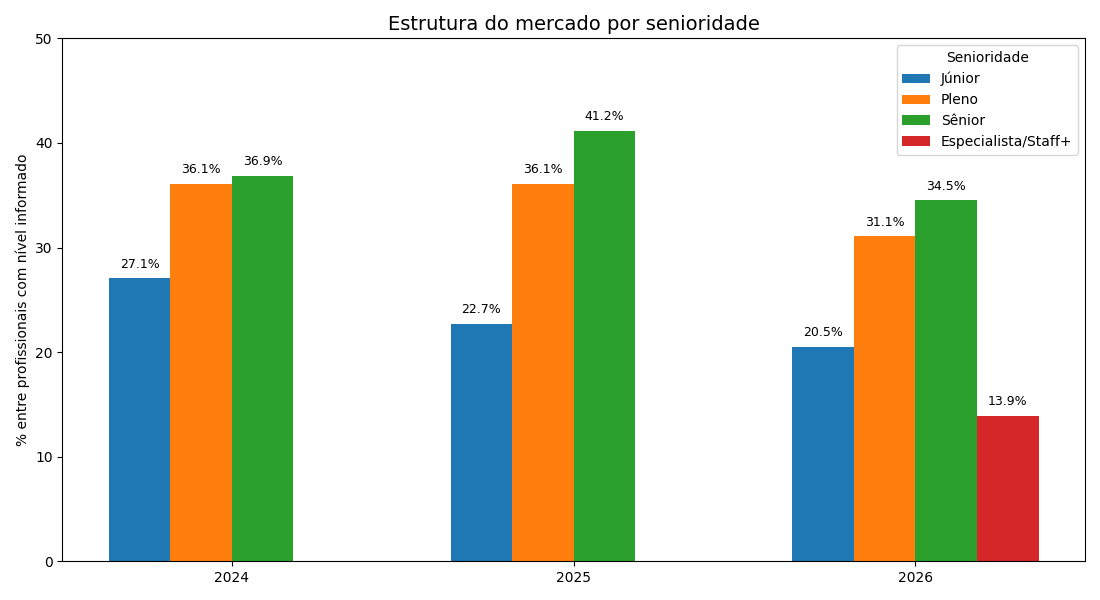

In [60]:
import numpy as np

df_grafico = estrutura_mercado.toPandas()

tabela = df_grafico.pivot(
    index="ano_pesquisa",
    columns="nivel",
    values="percentual"
)

ordem = [
    "Júnior",
    "Pleno",
    "Sênior",
    "Especialista/Staff+"
]

tabela = tabela.reindex(
    columns=[x for x in ordem if x in tabela.columns]
)

anos = tabela.index.astype(str).tolist()
x = np.arange(len(anos))

largura = 0.18

plt.figure(figsize=(11, 6))

for i, nivel in enumerate(tabela.columns):

    valores = tabela[nivel].values

    posicao = x + (
        i - (len(tabela.columns) - 1) / 2
    ) * largura

    plt.bar(
        posicao,
        valores,
        width=largura,
        label=nivel
    )

    for j, valor in enumerate(valores):

        if not np.isnan(valor):

            plt.text(
                posicao[j],
                valor + 1,
                f"{valor:.1f}%",
                ha="center",
                fontsize=9
            )

plt.xticks(
    x,
    ["2024", "2025", "2026"]
)

plt.ylabel("% entre profissionais com nível informado")
plt.xlabel("")

plt.title(
    "Estrutura do mercado por senioridade",
    fontsize=14
)

plt.ylim(0, 50)

plt.legend(title="Senioridade")

plt.tight_layout()

%matplot plt

In [61]:
cargo_mercado = (
    perfil_analise
    .filter(
        (F.col("situacao_mercado") == "Ativo no mercado") &
        F.col("cargo_atual").isNotNull()
    )
    .groupBy("ano_pesquisa", "cargo_atual")
    .count()
    .withColumnRenamed("count", "qtd_profissionais")
    .orderBy(
        "ano_pesquisa",
        F.desc("qtd_profissionais")
    )
)

cargo_mercado.show(truncate=False)

+------------+-------------------------------------------------------------------+-----------------+
|ano_pesquisa|cargo_atual                                                        |qtd_profissionais|
+------------+-------------------------------------------------------------------+-----------------+
|2023_2024   |Analista de Dados/Data Analyst                                     |906              |
|2023_2024   |Cientista de Dados/Data Scientist                                  |686              |
|2023_2024   |Engenheiro de Dados/Arquiteto de Dados/Data Engineer/Data Architect|682              |
|2023_2024   |Analista de BI/BI Analyst                                          |506              |
|2023_2024   |Outra Opção                                                        |259              |
|2023_2024   |Analista de Negócios/Business Analyst                              |195              |
|2023_2024   |Analytics Engineer                                                 |139      

In [62]:
cargo_mercado = (
    perfil_analise
    .filter(
        (F.col("situacao_mercado") == "Ativo no mercado") &
        F.col("cargo_atual").isNotNull()
    )
    .groupBy("ano_pesquisa", "cargo_atual")
    .count()
    .withColumnRenamed("count", "qtd_profissionais")
)

In [63]:
total_com_cargo = (
    perfil_analise
    .filter(
        (F.col("situacao_mercado") == "Ativo no mercado") &
        F.col("cargo_atual").isNotNull()
    )
    .groupBy("ano_pesquisa")
    .count()
    .withColumnRenamed("count", "total_com_cargo")
)

In [64]:
cargo_mercado = (
    cargo_mercado
    .join(
        total_com_cargo,
        on="ano_pesquisa",
        how="left"
    )
    .withColumn(
        "percentual",
        F.round(
            (F.col("qtd_profissionais") / F.col("total_com_cargo")) * 100,
            2
        )
    )
    .orderBy(
        "ano_pesquisa",
        F.desc("percentual")
    )
)

from pyspark.sql.window import Window

janela_cargo = Window.partitionBy("ano_pesquisa").orderBy(
    F.desc("percentual")
)

top5_cargos = (
    cargo_mercado
    .withColumn(
        "ranking",
        F.row_number().over(janela_cargo)
    )
    .filter(F.col("ranking") <= 5)
    .orderBy("ano_pesquisa", "ranking")
)

top5_cargos.show(100, truncate=False)

+------------+-------------------------------------------------------------------+-----------------+---------------+----------+-------+
|ano_pesquisa|cargo_atual                                                        |qtd_profissionais|total_com_cargo|percentual|ranking|
+------------+-------------------------------------------------------------------+-----------------+---------------+----------+-------+
|2023_2024   |Analista de Dados/Data Analyst                                     |906              |3850           |23.53     |1      |
|2023_2024   |Cientista de Dados/Data Scientist                                  |686              |3850           |17.82     |2      |
|2023_2024   |Engenheiro de Dados/Arquiteto de Dados/Data Engineer/Data Architect|682              |3850           |17.71     |3      |
|2023_2024   |Analista de BI/BI Analyst                                          |506              |3850           |13.14     |4      |
|2023_2024   |Outra Opção                       

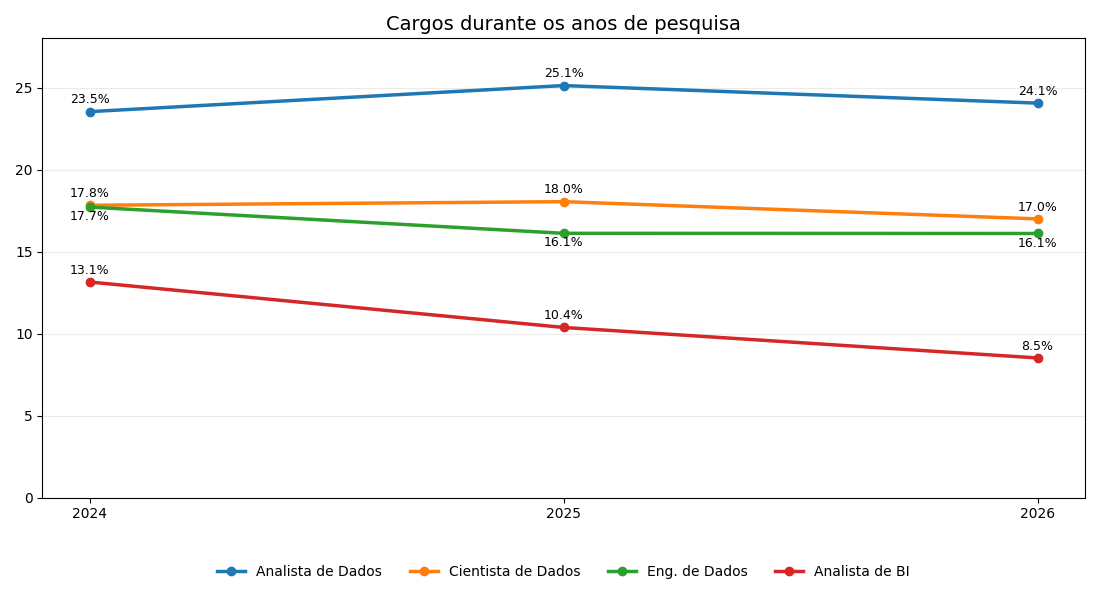

In [70]:
df_grafico = top5_cargos.toPandas()

df_grafico["cargo_grafico"] = df_grafico["cargo_atual"].apply(
    lambda x: "Analista de Dados"
    if "Analista de Dados" in x
    else "Cientista de Dados"
    if "Cientista de Dados" in x
    else "Eng. de Dados"
    if "Engenheiro de Dados" in x
    else "Analista de BI"
    if "Analista de BI" in x
    else "Outra"
)

cargos = [
    "Analista de Dados",
    "Cientista de Dados",
    "Eng. de Dados",
    "Analista de BI"
]

df_grafico = df_grafico[
    df_grafico["cargo_grafico"].isin(cargos)
].copy()

tabela = df_grafico.pivot(
    index="ano_pesquisa",
    columns="cargo_grafico",
    values="percentual"
)

tabela = tabela.reindex(columns=cargos)

tabela = tabela.reindex(
    ["2023_2024", "2024_2025", "2025_2026"]
)

anos = ["2024", "2025", "2026"]

plt.figure(figsize=(11, 6))

deslocamentos = {
    "Analista de Dados": 0.5,
    "Cientista de Dados": 0.5,
    "Eng. de Dados": -0.8,
    "Analista de BI": 0.5
}

for cargo in cargos:

    valores = tabela[cargo].values

    linha = plt.plot(
        anos,
        valores,
        marker="o",
        linewidth=2.5,
        label=cargo
    )

    for i, valor in enumerate(valores):

        deslocamento = deslocamentos[cargo]

        plt.text(
            i,
            valor + deslocamento,
            f"{valor:.1f}%",
            ha="center",
            fontsize=9
        )

plt.xlabel("")

plt.title(
    "Cargos durante os anos de pesquisa",
    fontsize=14
)

plt.ylim(0, 28)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=4,
    frameon=False
)

plt.tight_layout()

%matplot plt

In [71]:
regiao_mercado = (
    perfil_analise
    .filter(
        (F.col("situacao_mercado") == "Ativo no mercado") &
        F.col("regiao").isNotNull()
    )
    .groupBy("ano_pesquisa", "regiao")
    .count()
    .withColumnRenamed("count", "qtd_profissionais")
    .orderBy(
        "ano_pesquisa",
        F.desc("qtd_profissionais")
    )
)

regiao_mercado.show(truncate=False)

+------------+------------+-----------------+
|ano_pesquisa|regiao      |qtd_profissionais|
+------------+------------+-----------------+
|2023_2024   |Sudeste     |2907             |
|2023_2024   |Sul         |891              |
|2023_2024   |Nordeste    |518              |
|2023_2024   |Centro-oeste|310              |
|2023_2024   |Norte       |70               |
|2024_2025   |Sudeste     |2954             |
|2024_2025   |Sul         |995              |
|2024_2025   |Nordeste    |453              |
|2024_2025   |Centro-oeste|302              |
|2024_2025   |Norte       |56               |
|2025_2026   |Sudeste     |2030             |
|2025_2026   |Sul         |512              |
|2025_2026   |Nordeste    |336              |
|2025_2026   |Centro-oeste|218              |
|2025_2026   |Norte       |41               |
+------------+------------+-----------------+


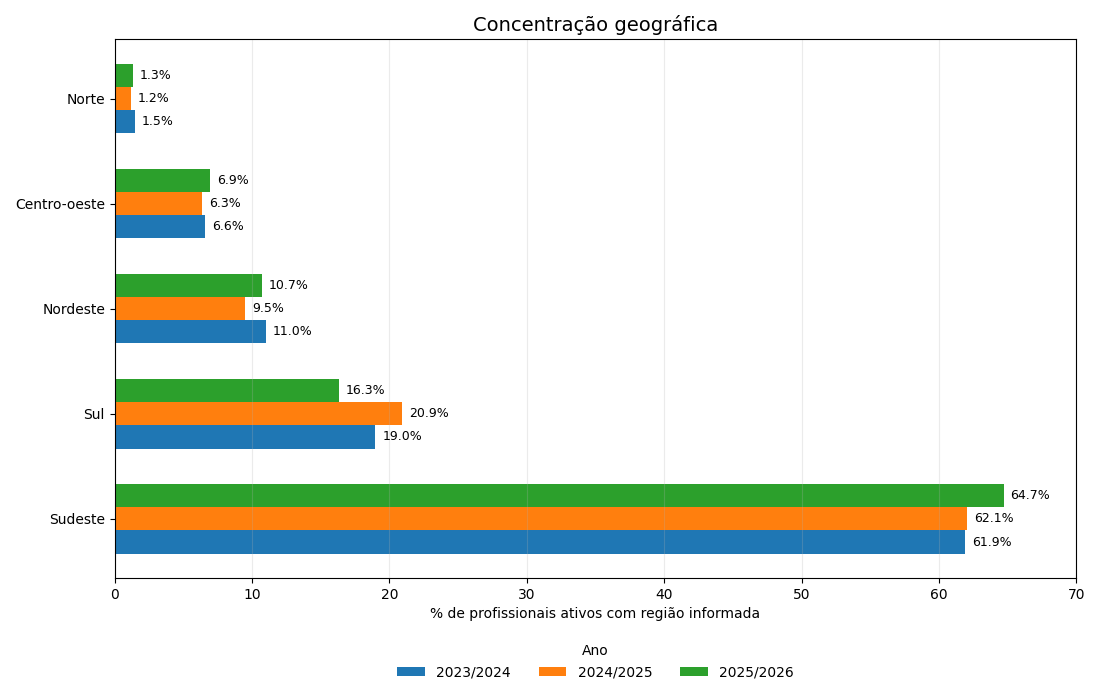

In [74]:
df_grafico = regiao_mercado.toPandas()

df_grafico["total_ano"] = (
    df_grafico
    .groupby("ano_pesquisa")["qtd_profissionais"]
    .transform("sum")
)

df_grafico["percentual"] = (
    df_grafico["qtd_profissionais"] /
    df_grafico["total_ano"] * 100
)

tabela = df_grafico.pivot(
    index="regiao",
    columns="ano_pesquisa",
    values="percentual"
)

regioes = [
    "Sudeste",
    "Sul",
    "Nordeste",
    "Centro-oeste",
    "Norte"
]

tabela = tabela.reindex(regioes)

anos = [
    "2023_2024",
    "2024_2025",
    "2025_2026"
]

tabela = tabela[anos]

y = np.arange(len(regioes))
largura = 0.22

plt.figure(figsize=(11, 7))

for i, ano in enumerate(anos):

    valores = tabela[ano].values

    posicao = y + (i - 1) * largura

    barras = plt.barh(
        posicao,
        valores,
        height=largura,
        label=ano.replace("_", "/")
    )

    for barra, valor in zip(barras, valores):

        plt.text(
            valor + 0.5,
            barra.get_y() + barra.get_height() / 2,
            f"{valor:.1f}%",
            va="center",
            fontsize=9
        )

plt.yticks(
    y,
    regioes
)

plt.xlabel(
    "% de profissionais ativos com região informada"
)

plt.ylabel("")

plt.title(
    "Concentração geográfica",
    fontsize=14
)

plt.xlim(0, 70)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.legend(
    title="Ano",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=3,
    frameon=False
)

plt.tight_layout()

%matplot plt

In [75]:
total_com_regiao = (
    perfil_analise
    .filter(
        (F.col("situacao_mercado") == "Ativo no mercado") &
        F.col("regiao").isNotNull()
    )
    .groupBy("ano_pesquisa")
    .count()
    .withColumnRenamed("count", "total_com_regiao")
)

regiao_mercado = (
    regiao_mercado
    .join(
        total_com_regiao,
        on="ano_pesquisa",
        how="left"
    )
    .withColumn(
        "percentual",
        F.round(
            (F.col("qtd_profissionais") / F.col("total_com_regiao")) * 100,
            2
        )
    )
    .orderBy(
        "ano_pesquisa",
        F.desc("percentual")
    )
)

regiao_mercado.show(100, truncate=False)

+------------+------------+-----------------+----------------+----------+
|ano_pesquisa|regiao      |qtd_profissionais|total_com_regiao|percentual|
+------------+------------+-----------------+----------------+----------+
|2023_2024   |Sudeste     |2907             |4696            |61.9      |
|2023_2024   |Sul         |891              |4696            |18.97     |
|2023_2024   |Nordeste    |518              |4696            |11.03     |
|2023_2024   |Centro-oeste|310              |4696            |6.6       |
|2023_2024   |Norte       |70               |4696            |1.49      |
|2024_2025   |Sudeste     |2954             |4760            |62.06     |
|2024_2025   |Sul         |995              |4760            |20.9      |
|2024_2025   |Nordeste    |453              |4760            |9.52      |
|2024_2025   |Centro-oeste|302              |4760            |6.34      |
|2024_2025   |Norte       |56               |4760            |1.18      |
|2025_2026   |Sudeste     |2030       

In [76]:
perfil_analise.select(
    "atua_como_gestor"
).distinct().show(truncate=False)

+----------------+
|atua_como_gestor|
+----------------+
|1               |
|null            |
|0               |
|FALSE           |
|TRUE            |
+----------------+


In [77]:
perfil_analise.groupBy(
    "ano_pesquisa",
    "atua_como_gestor"
).count().orderBy(
    "ano_pesquisa",
    "atua_como_gestor"
).show(100, truncate=False)

# existe um valor em texto que nao esta permitindo contabilizar como verdadeiro ou falso, vamos padronizar

+------------+----------------+-----+
|ano_pesquisa|atua_como_gestor|count|
+------------+----------------+-----+
|2023_2024   |null            |540  |
|2023_2024   |0               |3857 |
|2023_2024   |1               |896  |
|2024_2025   |null            |354  |
|2024_2025   |FALSE           |3816 |
|2024_2025   |TRUE            |1045 |
|2025_2026   |null            |267  |
|2025_2026   |0               |2500 |
|2025_2026   |1               |727  |
+------------+----------------+-----+


In [78]:
perfil_analise = (
    perfil_analise
    .withColumn(
        "perfil_gestao",
        F.when(
            F.col("atua_como_gestor").isin("1", "TRUE"),
            "Gestor"
        )
        .when(
            F.col("atua_como_gestor").isin("0", "FALSE"),
            "Não gestor"
        )
        .when(
            F.col("atua_como_gestor") == "Setor Público",
            "Setor Público"
        )
        .otherwise(None)
    )
)


In [79]:
gestao_mercado = (
    perfil_analise
    .filter(
        (F.col("situacao_mercado") == "Ativo no mercado") &
        F.col("perfil_gestao").isNotNull()
    )
    .groupBy("ano_pesquisa", "perfil_gestao")
    .count()
    .withColumnRenamed("count", "qtd_profissionais")
)

In [80]:
total_com_gestao = (
    perfil_analise
    .filter(
        (F.col("situacao_mercado") == "Ativo no mercado") &
        F.col("perfil_gestao").isin("Gestor", "Não gestor")
    )
    .groupBy("ano_pesquisa")
    .count()
    .withColumnRenamed("count", "total_com_gestao")
)

In [81]:
gestao_mercado = (
    gestao_mercado
    .join(total_com_gestao, on="ano_pesquisa", how="left")
    .withColumn(
        "percentual",
        F.round(
            (F.col("qtd_profissionais") / F.col("total_com_gestao")) * 100,
            2
        )
    )
    .orderBy("ano_pesquisa", F.desc("percentual"))
)

In [82]:
gestao_mercado.show(truncate=False)

+------------+-------------+-----------------+----------------+----------+
|ano_pesquisa|perfil_gestao|qtd_profissionais|total_com_gestao|percentual|
+------------+-------------+-----------------+----------------+----------+
|2023_2024   |Não gestor   |3850             |4743            |81.17     |
|2023_2024   |Gestor       |893              |4743            |18.83     |
|2024_2025   |Não gestor   |3798             |4834            |78.57     |
|2024_2025   |Gestor       |1036             |4834            |21.43     |
|2025_2026   |Não gestor   |2478             |3199            |77.46     |
|2025_2026   |Gestor       |721              |3199            |22.54     |
+------------+-------------+-----------------+----------------+----------+


In [83]:
perfil_salario = (
    perfil_analise
    .withColumn(
        "ordem_salarial",
        F.when(F.col("faixa_salarial") == "Menos de R$ 1.000/mês", 1)
        .when(F.col("faixa_salarial") == "de R$ 1.001/mês a R$ 2.000/mês", 2)
        .when(F.col("faixa_salarial") == "de R$ 2.001/mês a R$ 3.000/mês", 3)
        .when(F.col("faixa_salarial") == "de R$ 3.001/mês a R$ 4.000/mês", 4)
        .when(F.col("faixa_salarial") == "de R$ 4.001/mês a R$ 6.000/mês", 5)
        .when(F.col("faixa_salarial") == "de R$ 6.001/mês a R$ 8.000/mês", 6)
        .when(F.col("faixa_salarial") == "de R$ 8.001/mês a R$ 12.000/mês", 7)
        .when(F.col("faixa_salarial") == "de R$ 12.001/mês a R$ 16.000/mês", 8)
        .when(F.col("faixa_salarial") == "de R$ 16.001/mês a R$ 20.000/mês", 9)
        .when(F.col("faixa_salarial") == "de R$ 20.001/mês a R$ 25.000/mês", 10)
        .when(F.col("faixa_salarial") == "de R$ 25.001/mês a R$ 30.000/mês", 11)
        .when(F.col("faixa_salarial") == "de R$ 30.001/mês a R$ 40.000/mês", 12)
        .when(F.col("faixa_salarial") == "Acima de R$ 40.001/mês", 13)
    )
)

# desconsideramos 2 faixas problematicas com range errado (como "de R$ 25.001/mês a R$ 3000/mês" e "de R$ 101/mês a R$ 2.000/mês", apenas 2 casos)

In [84]:
salario_senioridade = (
    perfil_salario
    .filter(
        (F.col("situacao_mercado") == "Ativo no mercado") &
        F.col("nivel").isNotNull() &
        F.col("ordem_salarial").isNotNull()
    )
    .groupBy(
        "ano_pesquisa",
        "nivel",
        "faixa_salarial",
        "ordem_salarial"
    )
    .count()
    .withColumnRenamed("count", "qtd_profissionais")
    .orderBy(
        "ano_pesquisa",
        "nivel",
        "ordem_salarial"
    )
)

In [85]:
total_por_nivel = (
    salario_senioridade
    .groupBy(
        "ano_pesquisa",
        "nivel"
    )
    .agg(
        F.sum("qtd_profissionais").alias("total_nivel")
    )
)

In [86]:
salario_senioridade = (
    salario_senioridade
    .join(
        total_por_nivel,
        on=["ano_pesquisa", "nivel"],
        how="left"
    )
    .withColumn(
        "percentual",
        F.round(
            (F.col("qtd_profissionais") / F.col("total_nivel")) * 100,
            2
        )
    )
    .orderBy(
        "ano_pesquisa",
        "nivel",
        "ordem_salarial"
    )
)

In [87]:
salario_nivel_resumido = (
    salario_senioridade
    .withColumn(
        "faixa_salarial_grupo",
        F.when(
            F.col("ordem_salarial") <= 4,
            "Até R$ 4 mil"
        )
        .when(
            F.col("ordem_salarial") <= 7,
            "R$ 4.001 a R$ 12 mil"
        )
        .otherwise(
            "Acima de R$ 12 mil"
        )
    )
    .groupBy(
        "ano_pesquisa",
        "nivel",
        "faixa_salarial_grupo"
    )
    .agg(
        F.sum("qtd_profissionais").alias("qtd_profissionais")
    )
)

In [88]:
total_resumido = (
    salario_nivel_resumido
    .groupBy("ano_pesquisa", "nivel")
    .agg(
        F.sum("qtd_profissionais").alias("total_nivel")
    )
)

In [89]:
salario_nivel_resumido = (
    salario_nivel_resumido
    .join(
        total_resumido,
        on=["ano_pesquisa", "nivel"],
        how="left"
    )
    .withColumn(
        "percentual",
        F.round(
            (F.col("qtd_profissionais") / F.col("total_nivel")) * 100,
            2
        )
    )
    .orderBy(
        "ano_pesquisa",
        "nivel",
        "faixa_salarial_grupo"
    )
)

salario_nivel_resumido.show(100, truncate=False)

+------------+-------------------+--------------------+-----------------+-----------+----------+
|ano_pesquisa|nivel              |faixa_salarial_grupo|qtd_profissionais|total_nivel|percentual|
+------------+-------------------+--------------------+-----------------+-----------+----------+
|2023_2024   |Júnior             |Acima de R$ 12 mil  |8                |1041       |0.77      |
|2023_2024   |Júnior             |Até R$ 4 mil        |617              |1041       |59.27     |
|2023_2024   |Júnior             |R$ 4.001 a R$ 12 mil|416              |1041       |39.96     |
|2023_2024   |Pleno              |Acima de R$ 12 mil  |119              |1389       |8.57      |
|2023_2024   |Pleno              |Até R$ 4 mil        |197              |1389       |14.18     |
|2023_2024   |Pleno              |R$ 4.001 a R$ 12 mil|1073             |1389       |77.25     |
|2023_2024   |Sênior             |Acima de R$ 12 mil  |704              |1419       |49.61     |
|2023_2024   |Sênior          

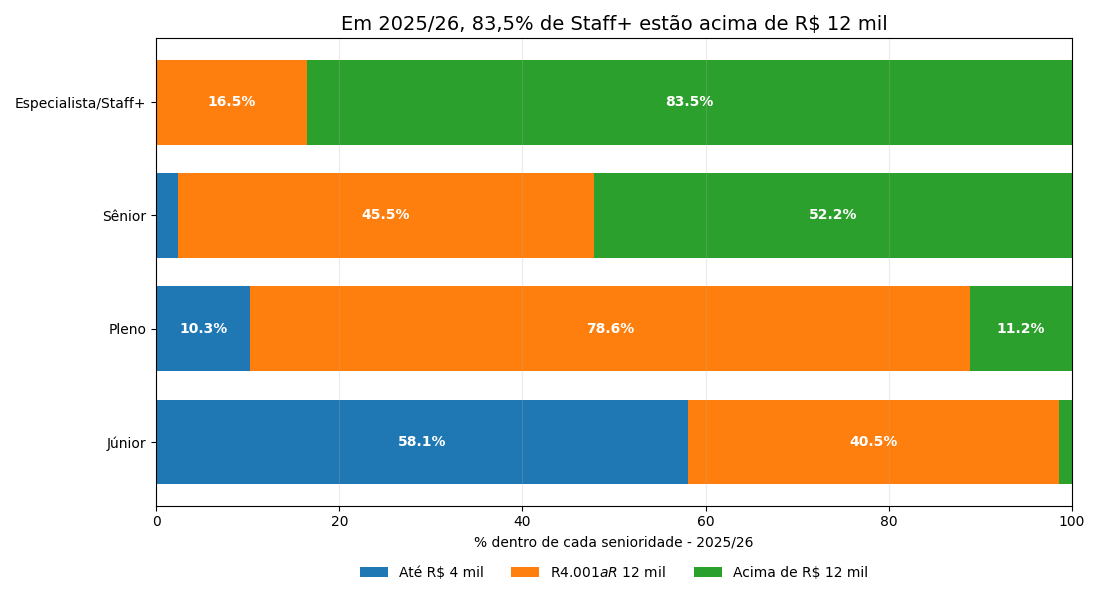

In [91]:
df_grafico = salario_nivel_resumido.toPandas()

# Pegamos somente 2026
df_2026 = df_grafico[
    df_grafico["ano_pesquisa"] == "2025_2026"
].copy()

ordem_niveis = [
    "Júnior",
    "Pleno",
    "Sênior",
    "Especialista/Staff+"
]

df_2026["nivel"] = pd.Categorical(
    df_2026["nivel"],
    categories=ordem_niveis,
    ordered=True
)

df_2026 = df_2026.sort_values("nivel")

tabela = df_2026.pivot(
    index="nivel",
    columns="faixa_salarial_grupo",
    values="percentual"
)

faixas = [
    "Até R$ 4 mil",
    "R$ 4.001 a R$ 12 mil",
    "Acima de R$ 12 mil"
]

tabela = tabela.reindex(columns=faixas)

plt.figure(figsize=(11, 6))

posicoes = range(len(tabela))

base = [0] * len(tabela)

for faixa in faixas:

    valores = tabela[faixa].fillna(0).values

    barras = plt.barh(
        posicoes,
        valores,
        left=base,
        height=0.75,
        label=faixa
    )

    for barra, valor in zip(barras, valores):

        if valor >= 5:

            plt.text(
                barra.get_x() + barra.get_width() / 2,
                barra.get_y() + barra.get_height() / 2,
                f"{valor:.1f}%",
                ha="center",
                va="center",
                fontsize=10,
                color="white",
                fontweight="bold"
            )

    base = [
        b + v
        for b, v in zip(base, valores)
    ]

plt.yticks(
    posicoes,
    tabela.index
)

plt.xlabel(
    "% dentro de cada senioridade - 2025/26"
)

plt.ylabel("")

plt.title(
    "Em 2025/26, 83,5% de Staff+ estão acima de R$ 12 mil",
    fontsize=14
)

plt.xlim(0, 100)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=3,
    frameon=False
)

plt.tight_layout()

%matplot plt

In [92]:
perfil_analise = (
    perfil_analise
    .withColumn(
        "cargo_analise",
        F.when(
            F.col("cargo_atual").isin(
                "Engenheiro de Dados/Arquiteto de Dados/Data Engineer/Data Architect",
                "Engenheiro de Dados/Data Engineer/Data Architect"
            ),
            "Engenheiro de Dados/Data Engineer/Data Architect"
        )
        .otherwise(F.col("cargo_atual"))
    )
)

# nomes diferentes para o cargo de engenheiro

In [93]:
cargos_principais = [
    "Analista de Dados/Data Analyst",
    "Cientista de Dados/Data Scientist",
    "Engenheiro de Dados/Data Engineer/Data Architect",
    "Analista de BI/BI Analyst"
]

cargo_salario = (
    perfil_salario
    .withColumn(
        "cargo_analise",
        F.when(
            F.col("cargo_atual").isin(
                "Engenheiro de Dados/Arquiteto de Dados/Data Engineer/Data Architect",
                "Engenheiro de Dados/Data Engineer/Data Architect"
            ),
            "Engenheiro de Dados/Data Engineer/Data Architect"
        )
        .otherwise(F.col("cargo_atual"))
    )
    .filter(
        (F.col("situacao_mercado") == "Ativo no mercado") &
        F.col("cargo_analise").isin(cargos_principais) &
        F.col("ordem_salarial").isNotNull()
    )
    .withColumn(
        "faixa_salarial_grupo",
        F.when(
            F.col("ordem_salarial") <= 4,
            "Até R$ 4 mil"
        )
        .when(
            F.col("ordem_salarial") <= 7,
            "R$ 4.001 a R$ 12 mil"
        )
        .otherwise("Acima de R$ 12 mil")
    )
    .groupBy(
        "ano_pesquisa",
        "cargo_analise",
        "faixa_salarial_grupo"
    )
    .count()
    .withColumnRenamed("count", "qtd_profissionais")
)

In [94]:
total_cargo = (
    cargo_salario
    .groupBy(
        "ano_pesquisa",
        "cargo_analise"
    )
    .agg(
        F.sum("qtd_profissionais").alias("total_cargo")
    )
)

cargo_salario = (
    cargo_salario
    .join(
        total_cargo,
        on=["ano_pesquisa", "cargo_analise"],
        how="left"
    )
    .withColumn(
        "percentual",
        F.round(
            (F.col("qtd_profissionais") / F.col("total_cargo")) * 100,
            2
        )
    )
    .orderBy(
        "ano_pesquisa",
        "cargo_analise",
        "faixa_salarial_grupo"
    )
)

cargo_salario.show(100, truncate=False)

+------------+------------------------------------------------+--------------------+-----------------+-----------+----------+
|ano_pesquisa|cargo_analise                                   |faixa_salarial_grupo|qtd_profissionais|total_cargo|percentual|
+------------+------------------------------------------------+--------------------+-----------------+-----------+----------+
|2023_2024   |Analista de BI/BI Analyst                       |Acima de R$ 12 mil  |32               |506        |6.32      |
|2023_2024   |Analista de BI/BI Analyst                       |Até R$ 4 mil        |160              |506        |31.62     |
|2023_2024   |Analista de BI/BI Analyst                       |R$ 4.001 a R$ 12 mil|314              |506        |62.06     |
|2023_2024   |Analista de Dados/Data Analyst                  |Acima de R$ 12 mil  |95               |906        |10.49     |
|2023_2024   |Analista de Dados/Data Analyst                  |Até R$ 4 mil        |229              |906        |25.2

<stdin>:56: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).



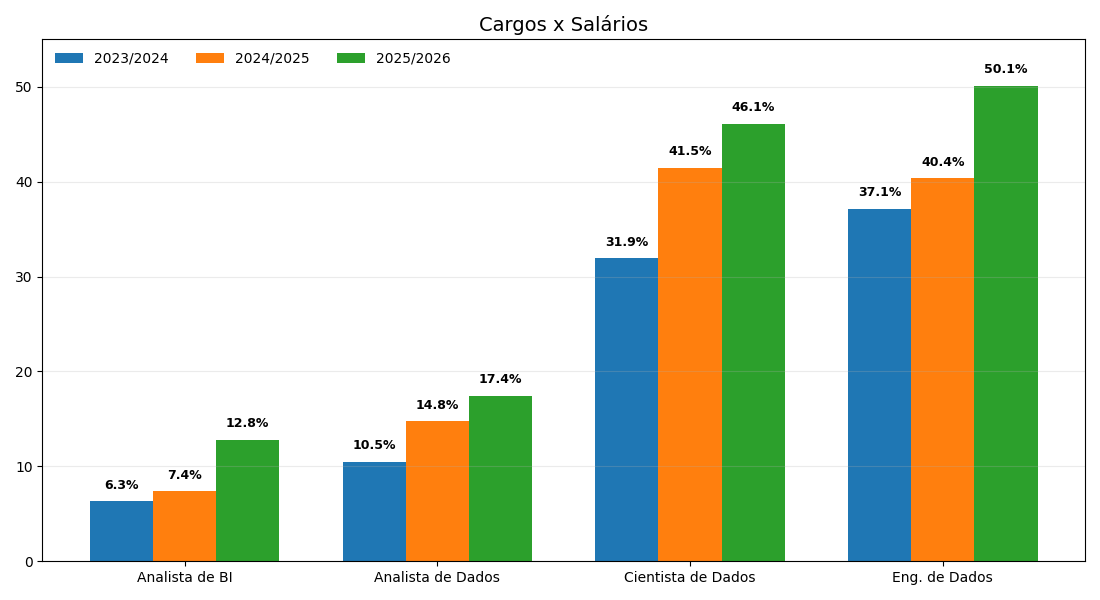

In [98]:
df_grafico = cargo_salario.toPandas()

df_grafico["cargo_grafico"] = df_grafico["cargo_analise"].apply(
    lambda x: "Analista de BI"
    if "Analista de BI" in x
    else "Analista de Dados"
    if "Analista de Dados" in x
    else "Cientista de Dados"
    if "Cientista de Dados" in x
    else "Eng. de Dados"
    if "Engenheiro de Dados" in x
    else "Outro"
)

cargos = [
    "Analista de BI",
    "Analista de Dados",
    "Cientista de Dados",
    "Eng. de Dados"
]

df_grafico = df_grafico[
    df_grafico["cargo_grafico"].isin(cargos)
].copy()

df_grafico = df_grafico[
    df_grafico["faixa_salarial_grupo"] == "Acima de R$ 12 mil"
].copy()

tabela = df_grafico.pivot(
    index="cargo_grafico",
    columns="ano_pesquisa",
    values="percentual"
)

tabela = tabela.reindex(cargos)

anos = [
    "2023_2024",
    "2024_2025",
    "2025_2026"
]

tabela = tabela[anos]

x = np.arange(len(cargos))
largura = 0.25

plt.figure(figsize=(11, 6))

for i, ano in enumerate(anos):

    valores = tabela[ano].values

    posicao = x + (i - 1) * largura

    barras = plt.bar(
        posicao,
        valores,
        width=largura,
        label=ano.replace("_", "/")
    )

    for barra, valor in zip(barras, valores):

        plt.text(
            barra.get_x() + barra.get_width() / 2,
            valor + 1,
            f"{valor:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

plt.xticks(
    x,
    cargos
)

plt.xlabel("")

plt.title(
    "Cargos x Salários",
    fontsize=14
)

plt.ylim(0, 55)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.legend(
    loc="upper left",
    frameon=False,
    ncol=3
)

plt.tight_layout()

%matplot plt

In [104]:
cargo_nivel_salario = (
    perfil_salario
    .withColumn(
        "cargo_analise",
        F.when(
            F.col("cargo_atual").isin(
                "Engenheiro de Dados/Arquiteto de Dados/Data Engineer/Data Architect",
                "Engenheiro de Dados/Data Engineer/Data Architect"
            ),
            "Engenheiro de Dados/Data Engineer/Data Architect"
        )
        .otherwise(F.col("cargo_atual"))
    )
    .filter(
        (F.col("situacao_mercado") == "Ativo no mercado") &
        F.col("cargo_analise").isin(cargos_principais) &
        F.col("nivel").isNotNull() &
        F.col("ordem_salarial").isNotNull()
    )
    .withColumn(
        "faixa_salarial_grupo",
        F.when(
            F.col("ordem_salarial") <= 4,
            "Até R$ 4 mil"
        )
        .when(
            F.col("ordem_salarial") <= 7,
            "R$ 4.001 a R$ 12 mil"
        )
        .otherwise("Acima de R$ 12 mil")
    )
    .groupBy(
        "ano_pesquisa",
        "cargo_analise",
        "nivel",
        "faixa_salarial_grupo"
    )
    .count()
    .withColumnRenamed("count", "qtd_profissionais")
)

In [105]:
total_cargo_nivel = (
    cargo_nivel_salario
    .groupBy(
        "ano_pesquisa",
        "cargo_analise",
        "nivel"
    )
    .agg(
        F.sum("qtd_profissionais").alias("total_cargo_nivel")
    )
)

cargo_nivel_salario = (
    cargo_nivel_salario
    .join(
        total_cargo_nivel,
        on=[
            "ano_pesquisa",
            "cargo_analise",
            "nivel"
        ],
        how="left"
    )
    .withColumn(
        "percentual",
        F.round(
            (F.col("qtd_profissionais") /
             F.col("total_cargo_nivel")) * 100,
            2
        )
    )
    .orderBy(
        "ano_pesquisa",
        "cargo_analise",
        "nivel",
        "faixa_salarial_grupo"
    )
)

cargo_nivel_salario.show(200, truncate=False)

+------------+------------------------------------------------+-------------------+--------------------+-----------------+-----------------+----------+
|ano_pesquisa|cargo_analise                                   |nivel              |faixa_salarial_grupo|qtd_profissionais|total_cargo_nivel|percentual|
+------------+------------------------------------------------+-------------------+--------------------+-----------------+-----------------+----------+
|2023_2024   |Analista de BI/BI Analyst                       |Júnior             |Até R$ 4 mil        |125              |176              |71.02     |
|2023_2024   |Analista de BI/BI Analyst                       |Júnior             |R$ 4.001 a R$ 12 mil|51               |176              |28.98     |
|2023_2024   |Analista de BI/BI Analyst                       |Pleno              |Acima de R$ 12 mil  |6                |200              |3.0       |
|2023_2024   |Analista de BI/BI Analyst                       |Pleno              |Até R

In [46]:
genero_mercado = (
    perfil
    .filter(F.col("genero").isNotNull())
    .groupBy("ano_pesquisa", "genero")
    .count()
    .withColumnRenamed("count", "qtd_profissionais")
)

In [107]:
total_genero = (
    genero_mercado
    .groupBy("ano_pesquisa")
    .agg(
        F.sum("qtd_profissionais").alias("total_genero")
    )
)

In [108]:
genero_mercado = (
    genero_mercado
    .join(
        total_genero,
        on="ano_pesquisa",
        how="left"
    )
    .withColumn(
        "percentual",
        F.round(
            (F.col("qtd_profissionais") / F.col("total_genero")) * 100,
            2
        )
    )
    .orderBy(
        "ano_pesquisa",
        F.desc("percentual")
    )
)

genero_mercado.show(50, truncate=False)

+------------+--------------------+-----------------+------------+----------+
|ano_pesquisa|genero              |qtd_profissionais|total_genero|percentual|
+------------+--------------------+-----------------+------------+----------+
|2023_2024   |Masculino           |3975             |5293        |75.1      |
|2023_2024   |Feminino            |1293             |5293        |24.43     |
|2023_2024   |Prefiro não informar|16               |5293        |0.3       |
|2023_2024   |Outro               |9                |5293        |0.17      |
|2024_2025   |Masculino           |3967             |5215        |76.07     |
|2024_2025   |Feminino            |1225             |5215        |23.49     |
|2024_2025   |Prefiro não informar|15               |5215        |0.29      |
|2024_2025   |Outro               |8                |5215        |0.15      |
|2025_2026   |Masculino           |2707             |3494        |77.48     |
|2025_2026   |Feminino            |767              |3494       

In [109]:
genero_senioridade = (
    perfil
    .filter(
        F.col("genero").isNotNull() &
        F.col("nivel").isNotNull()
    )
    .groupBy(
        "ano_pesquisa",
        "genero",
        "nivel"
    )
    .count()
    .withColumnRenamed("count", "qtd_profissionais")
)

In [110]:
total_genero_nivel = (
    genero_senioridade
    .groupBy(
        "ano_pesquisa",
        "genero"
    )
    .agg(
        F.sum("qtd_profissionais").alias("total_genero")
    )
)

In [111]:
genero_senioridade = (
    genero_senioridade
    .join(
        total_genero_nivel,
        on=["ano_pesquisa", "genero"],
        how="left"
    )
    .withColumn(
        "percentual",
        F.round(
            (F.col("qtd_profissionais") / F.col("total_genero")) * 100,
            2
        )
    )
    .orderBy(
        "ano_pesquisa",
        "genero",
        F.desc("percentual")
    )
)

genero_senioridade.show(100, truncate=False)

+------------+--------------------+-------------------+-----------------+------------+----------+
|ano_pesquisa|genero              |nivel              |qtd_profissionais|total_genero|percentual|
+------------+--------------------+-------------------+-----------------+------------+----------+
|2023_2024   |Feminino            |Pleno              |337              |943         |35.74     |
|2023_2024   |Feminino            |Sênior             |307              |943         |32.56     |
|2023_2024   |Feminino            |Júnior             |299              |943         |31.71     |
|2023_2024   |Masculino           |Sênior             |1106             |2896        |38.19     |
|2023_2024   |Masculino           |Pleno              |1047             |2896        |36.15     |
|2023_2024   |Masculino           |Júnior             |743              |2896        |25.66     |
|2023_2024   |Outro               |Pleno              |4                |7           |57.14     |
|2023_2024   |Outro 

In [47]:
raca_mercado = (
    perfil
    .filter(F.col("raca").isNotNull())
    .groupBy(
        "ano_pesquisa",
        "raca"
    )
    .count()
    .withColumnRenamed(
        "count",
        "qtd_profissionais"
    )
)

In [113]:
total_raca = (
    raca_mercado
    .groupBy("ano_pesquisa")
    .agg(
        F.sum("qtd_profissionais").alias("total_raca")
    )
)

In [114]:
raca_mercado = (
    raca_mercado
    .join(
        total_raca,
        on="ano_pesquisa",
        how="left"
    )
    .withColumn(
        "percentual",
        F.round(
            (F.col("qtd_profissionais") / F.col("total_raca")) * 100,
            2
        )
    )
    .orderBy(
        "ano_pesquisa",
        F.desc("percentual")
    )
)

raca_mercado.show(100, truncate=False)

+------------+--------------------+-----------------+----------+----------+
|ano_pesquisa|raca                |qtd_profissionais|total_raca|percentual|
+------------+--------------------+-----------------+----------+----------+
|2023_2024   |Branca              |3414             |5293      |64.5      |
|2023_2024   |Parda               |1281             |5293      |24.2      |
|2023_2024   |Preta               |387              |5293      |7.31      |
|2023_2024   |Amarela             |147              |5293      |2.78      |
|2023_2024   |Prefiro não informar|34               |5293      |0.64      |
|2023_2024   |Outra               |18               |5293      |0.34      |
|2023_2024   |Indígena            |12               |5293      |0.23      |
|2024_2025   |Branca              |3477             |5215      |66.67     |
|2024_2025   |Parda               |1179             |5215      |22.61     |
|2024_2025   |Preta               |352              |5215      |6.75      |
|2024_2025  

In [51]:
pcd_mercado = (
    perfil
    .filter(F.col("pcd").isNotNull())
    .groupBy(
        "ano_pesquisa",
        "pcd"
    )
    .count()
    .withColumnRenamed(
        "count",
        "qtd_profissionais"
    )
)

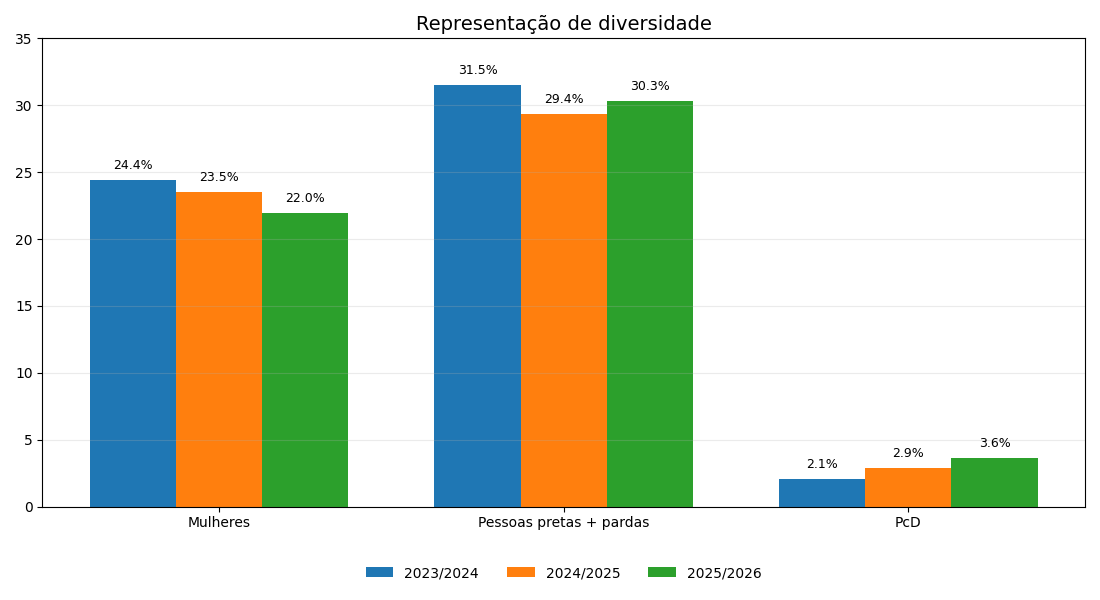

In [53]:
import numpy as np

df_genero = genero_mercado.toPandas()

total_genero = (
    df_genero
    .groupby("ano_pesquisa")["qtd_profissionais"]
    .sum()
)

mulheres = (
    df_genero[
        df_genero["genero"] == "Feminino"
    ]
    .set_index("ano_pesquisa")["qtd_profissionais"]
)

pct_mulheres = (
    mulheres / total_genero * 100
)

df_raca = raca_mercado.toPandas()

total_raca = (
    df_raca
    .groupby("ano_pesquisa")["qtd_profissionais"]
    .sum()
)

pretas_pardas = (
    df_raca[
        df_raca["raca"].isin(["Preta", "Parda"])
    ]
    .groupby("ano_pesquisa")["qtd_profissionais"]
    .sum()
)

pct_pretas_pardas = (
    pretas_pardas / total_raca * 100
)

df_pcd = pcd_mercado.toPandas()

total_pcd = (
    df_pcd
    .groupby("ano_pesquisa")["qtd_profissionais"]
    .sum()
)

pcd_sim = (
    df_pcd[
        df_pcd["pcd"] == "Sim"
    ]
    .set_index("ano_pesquisa")["qtd_profissionais"]
)

pct_pcd = (
    pcd_sim / total_pcd * 100
)

anos = [
    "2023_2024",
    "2024_2025",
    "2025_2026"
]

dados = pd.DataFrame({
    "Mulheres": pct_mulheres,
    "Pessoas pretas + pardas": pct_pretas_pardas,
    "PcD": pct_pcd
})

dados = dados.reindex(anos)

categorias = [
    "Mulheres",
    "Pessoas pretas + pardas",
    "PcD"
]

x = np.arange(len(categorias))
largura = 0.25

plt.figure(figsize=(11, 6))

for i, ano in enumerate(anos):

    valores = dados.loc[ano].values

    posicao = x + (i - 1) * largura

    barras = plt.bar(
        posicao,
        valores,
        width=largura,
        label=ano.replace("_", "/")
    )

    for barra, valor in zip(barras, valores):

        plt.text(
            barra.get_x() + barra.get_width() / 2,
            valor + 0.6,
            f"{valor:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )


plt.xticks(
    x,
    categorias
)


plt.xlabel("")

plt.title(
    "Representação de diversidade",
    fontsize=14
)

plt.ylim(0, 35)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=3,
    frameon=False
)

plt.tight_layout()

%matplot plt

In [116]:
total_pcd = (
    pcd_mercado
    .groupBy("ano_pesquisa")
    .agg(
        F.sum("qtd_profissionais").alias("total_pcd")
    )
)

pcd_mercado = (
    pcd_mercado
    .join(
        total_pcd,
        on="ano_pesquisa",
        how="left"
    )
    .withColumn(
        "percentual",
        F.round(
            (F.col("qtd_profissionais") / F.col("total_pcd")) * 100,
            2
        )
    )
    .orderBy(
        "ano_pesquisa",
        F.desc("percentual")
    )
)

pcd_mercado.show(50, truncate=False)

+------------+--------------------+-----------------+---------+----------+
|ano_pesquisa|pcd                 |qtd_profissionais|total_pcd|percentual|
+------------+--------------------+-----------------+---------+----------+
|2023_2024   |Não                 |5156             |5293     |97.41     |
|2023_2024   |Sim                 |111              |5293     |2.1       |
|2023_2024   |Prefiro não informar|26               |5293     |0.49      |
|2024_2025   |Não                 |5035             |5215     |96.55     |
|2024_2025   |Sim                 |152              |5215     |2.91      |
|2024_2025   |Prefiro não informar|28               |5215     |0.54      |
|2025_2026   |Não                 |3336             |3494     |95.48     |
|2025_2026   |Sim                 |127              |3494     |3.63      |
|2025_2026   |Prefiro não informar|31               |3494     |0.89      |
+------------+--------------------+-----------------+---------+----------+


In [117]:
experiencia_prejudicada = (
    perfil
    .groupBy("ano_pesquisa")
    .agg(
        F.sum("sem_experiencia_prej").alias("qtd_sem_prejuizo"),
        F.count("sem_experiencia_prej").alias("total_sem_prejuizo"),

        F.sum("experiencia_prej_raca").alias("qtd_prejuizo_raca"),
        F.count("experiencia_prej_raca").alias("total_prejuizo_raca"),

        F.sum("experiencia_prej_identidade").alias("qtd_prejuizo_genero"),
        F.count("experiencia_prej_identidade").alias("total_prejuizo_genero"),

        F.sum("experiencia_prej_pcd").alias("qtd_prejuizo_pcd"),
        F.count("experiencia_prej_pcd").alias("total_prejuizo_pcd")
    )
)

In [118]:
experiencia_prejudicada = (
    experiencia_prejudicada

    .withColumn(
        "percentual_sem_prejuizo",
        F.round(
            F.col("qtd_sem_prejuizo") /
            F.col("total_sem_prejuizo") * 100,
            2
        )
    )

    .withColumn(
        "percentual_prejuizo_raca",
        F.round(
            F.col("qtd_prejuizo_raca") /
            F.col("total_prejuizo_raca") * 100,
            2
        )
    )

    .withColumn(
        "percentual_prejuizo_genero",
        F.round(
            F.col("qtd_prejuizo_genero") /
            F.col("total_prejuizo_genero") * 100,
            2
        )
    )

    .withColumn(
        "percentual_prejuizo_pcd",
        F.round(
            F.col("qtd_prejuizo_pcd") /
            F.col("total_prejuizo_pcd") * 100,
            2
        )
    )
)

experiencia_prejudicada.show(truncate=False)

+------------+----------------+------------------+-----------------+-------------------+-------------------+---------------------+----------------+------------------+-----------------------+------------------------+--------------------------+-----------------------+
|ano_pesquisa|qtd_sem_prejuizo|total_sem_prejuizo|qtd_prejuizo_raca|total_prejuizo_raca|qtd_prejuizo_genero|total_prejuizo_genero|qtd_prejuizo_pcd|total_prejuizo_pcd|percentual_sem_prejuizo|percentual_prejuizo_raca|percentual_prejuizo_genero|percentual_prejuizo_pcd|
+------------+----------------+------------------+-----------------+-------------------+-------------------+---------------------+----------------+------------------+-----------------------+------------------------+--------------------------+-----------------------+
|2023_2024   |1474            |2719              |551              |2719               |792                |2719                 |67              |2719              |54.21                  |20.26    

In [55]:
fontes_dados = [
    "dados_sql",
    "dados_nosql",
    "imagens",
    "textos_documentos",
    "videos",
    "audios",
    "planilhas",
    "dados_georeferenciados"
]

fontes_dados_long = None

for coluna in fontes_dados:
    df_temp = tecnologias.select(
        "id",
        "ano_pesquisa",
        F.lit(coluna).alias("tecnologia"),
        F.col(coluna).alias("selecionou")
    )

    if fontes_dados_long is None:
        fontes_dados_long = df_temp
    else:
        fontes_dados_long = fontes_dados_long.unionByName(df_temp)

In [56]:
fontes_analise = (
    fontes_dados_long
    .filter(F.col("selecionou") == "1")
    .groupBy("ano_pesquisa", "tecnologia")
    .agg(F.countDistinct("id").alias("qtd_profissionais"))
)

In [57]:
total_fontes = (
    fontes_dados_long
    .filter(F.col("selecionou").isNotNull())
    .groupBy("ano_pesquisa")
    .agg(F.countDistinct("id").alias("total_profissionais"))
)

In [58]:
fontes_analise = (
    fontes_analise
    .join(total_fontes, on="ano_pesquisa", how="left")
    .withColumn(
        "percentual",
        F.round(
            (F.col("qtd_profissionais") / F.col("total_profissionais")) * 100,
            2
        )
    )
    .orderBy("ano_pesquisa", F.desc("percentual"))
)

fontes_analise.show(30, truncate=False)

+------------+----------------------+-----------------+-------------------+----------+
|ano_pesquisa|tecnologia            |qtd_profissionais|total_profissionais|percentual|
+------------+----------------------+-----------------+-------------------+----------+
|2023_2024   |planilhas             |3429             |3772               |90.91     |
|2023_2024   |dados_sql             |3388             |3772               |89.82     |
|2023_2024   |textos_documentos     |2177             |3772               |57.71     |
|2023_2024   |dados_nosql           |1367             |3772               |36.24     |
|2023_2024   |dados_georeferenciados|1140             |3772               |30.22     |
|2023_2024   |imagens               |576              |3772               |15.27     |
|2023_2024   |audios                |159              |3772               |4.22      |
|2023_2024   |videos                |153              |3772               |4.06      |
|2024_2025   |dados_sql             |3373  

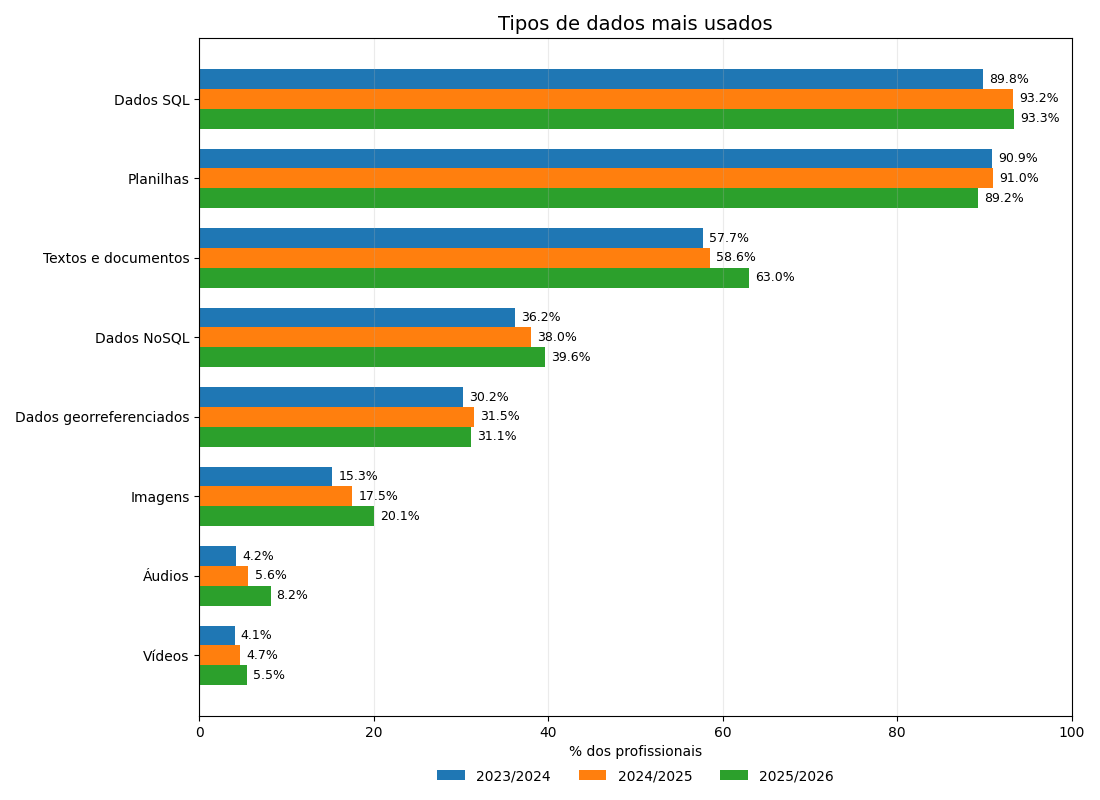

In [60]:
df_grafico = fontes_analise.toPandas()

nomes = {
    "dados_sql": "Dados SQL",
    "planilhas": "Planilhas",
    "textos_documentos": "Textos e documentos",
    "dados_nosql": "Dados NoSQL",
    "dados_georeferenciados": "Dados georreferenciados",
    "imagens": "Imagens",
    "audios": "Áudios",
    "videos": "Vídeos"
}

df_grafico["tecnologia_nome"] = (
    df_grafico["tecnologia"].map(nomes)
)

tipos = [
    "Dados SQL",
    "Planilhas",
    "Textos e documentos",
    "Dados NoSQL",
    "Dados georreferenciados",
    "Imagens",
    "Áudios",
    "Vídeos"
]

tabela = df_grafico.pivot(
    index="tecnologia_nome",
    columns="ano_pesquisa",
    values="percentual"
)

tabela = tabela.reindex(tipos)

anos = [
    "2023_2024",
    "2024_2025",
    "2025_2026"
]

tabela = tabela[anos]

y = np.arange(len(tipos))
largura = 0.25

plt.figure(figsize=(11, 8))

for i, ano in enumerate(anos):

    valores = tabela[ano].values

    posicao = y + (i - 1) * largura

    barras = plt.barh(
        posicao,
        valores,
        height=largura,
        label=ano.replace("_", "/")
    )

    for barra, valor in zip(barras, valores):

        plt.text(
            valor + 0.7,
            barra.get_y() + barra.get_height() / 2,
            f"{valor:.1f}%",
            va="center",
            fontsize=9
        )

plt.yticks(
    y,
    tipos
)

plt.xlabel("% dos profissionais")

plt.ylabel("")

plt.title(
    "Tipos de dados mais usados",
    fontsize=14
)

plt.xlim(0, 100)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.06),
    ncol=3,
    frameon=False
)

plt.gca().invert_yaxis()

plt.tight_layout()

%matplot plt

In [61]:
ferramentas_bi = [
    "powerbi",
    "qlik",
    "tableau",
    "metabase",
    "superset",
    "redash",
    "looker",
    "looker_studio",
    "quicksight",
    "alteryx",
    "sap_business_objects",
    "oracle_bi",
    "salesforce_einstein",
    "sas_visual_analytics",
    "grafana",
    "pentaho",
    "excel_planilhas",
    "nao_utiliza_bi"
]

In [62]:
resultados_bi = []

for coluna in ferramentas_bi:

    resultado = (
        tecnologias
        .groupBy("ano_pesquisa")
        .agg(
            F.count(
                F.when(F.col(coluna) == "1", 1)
            ).alias("qtd_profissionais"),
            F.count(
                F.col(coluna)
            ).alias("total_respostas")
        )
        .withColumn("tecnologia", F.lit(coluna))
    )

    resultados_bi.append(resultado)

In [63]:
bi_analise = resultados_bi[0]

for df_temp in resultados_bi[1:]:
    bi_analise = bi_analise.unionByName(df_temp)

In [64]:
bi_analise = (
    bi_analise
    .withColumn(
        "percentual",
        F.round(
            (F.col("qtd_profissionais") / F.col("total_respostas")) * 100,
            2
        )
    )
    .select(
        "ano_pesquisa",
        "tecnologia",
        "qtd_profissionais",
        "total_respostas",
        "percentual"
    )
    .orderBy(
        "ano_pesquisa",
        F.desc("percentual")
    )
)

bi_analise.show(60, truncate=False)

+------------+--------------------+-----------------+---------------+----------+
|ano_pesquisa|tecnologia          |qtd_profissionais|total_respostas|percentual|
+------------+--------------------+-----------------+---------------+----------+
|2023_2024   |powerbi             |2154             |3772           |57.1      |
|2023_2024   |looker              |898              |3772           |23.81     |
|2023_2024   |tableau             |713              |3772           |18.9      |
|2023_2024   |looker_studio       |653              |3772           |17.31     |
|2023_2024   |nao_utiliza_bi      |409              |3772           |10.84     |
|2023_2024   |excel_planilhas     |391              |3772           |10.37     |
|2023_2024   |metabase            |324              |3772           |8.59      |
|2023_2024   |grafana             |276              |3772           |7.32      |
|2023_2024   |qlik                |194              |3772           |5.14      |
|2023_2024   |pentaho       

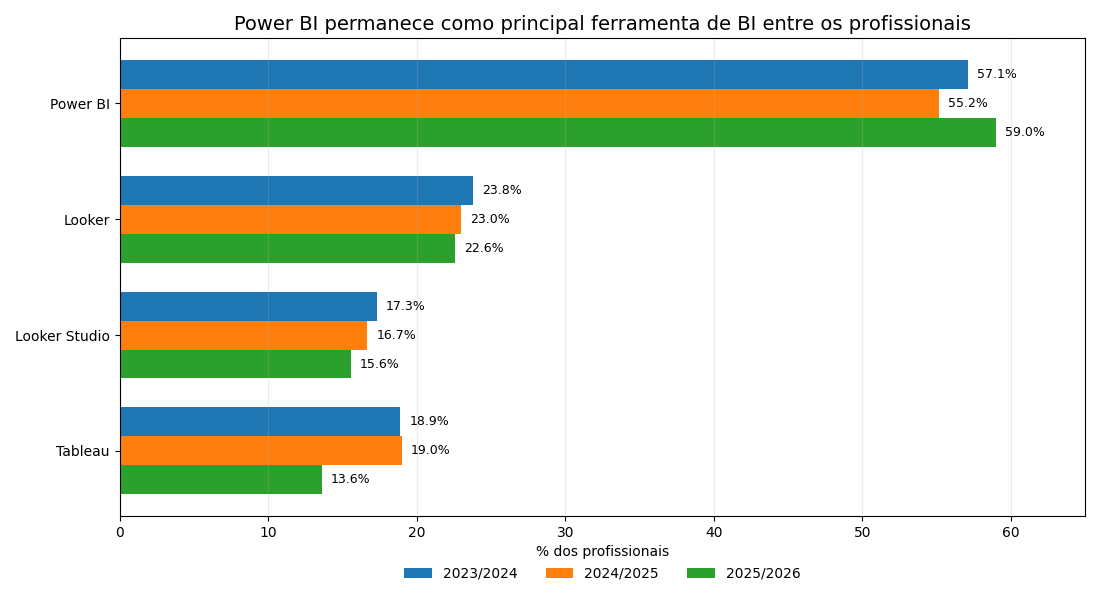

In [66]:
df_grafico = bi_analise.toPandas()

nomes = {
    "powerbi": "Power BI",
    "looker": "Looker",
    "looker_studio": "Looker Studio",
    "tableau": "Tableau"
}

df_grafico["tecnologia_nome"] = (
    df_grafico["tecnologia"].map(nomes)
)

ferramentas = [
    "Power BI",
    "Looker",
    "Looker Studio",
    "Tableau"
]

df_grafico = df_grafico[
    df_grafico["tecnologia_nome"].isin(ferramentas)
].copy()

tabela = df_grafico.pivot(
    index="tecnologia_nome",
    columns="ano_pesquisa",
    values="percentual"
)

tabela = tabela.reindex(ferramentas)

anos = [
    "2023_2024",
    "2024_2025",
    "2025_2026"
]

tabela = tabela[anos]

y = np.arange(len(ferramentas))
largura = 0.25

plt.figure(figsize=(11, 6))

for i, ano in enumerate(anos):

    valores = tabela[ano].values

    posicao = y + (i - 1) * largura

    barras = plt.barh(
        posicao,
        valores,
        height=largura,
        label=ano.replace("_", "/")
    )

    for barra, valor in zip(barras, valores):

        plt.text(
            valor + 0.6,
            barra.get_y() + barra.get_height() / 2,
            f"{valor:.1f}%",
            va="center",
            fontsize=9
        )

plt.yticks(
    y,
    ferramentas
)

plt.xlabel("% dos profissionais")

plt.ylabel("")

plt.title(
    "Power BI permanece como principal ferramenta de BI entre os profissionais",
    fontsize=14
)

plt.xlim(0, 65)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    frameon=False
)

plt.gca().invert_yaxis()

plt.tight_layout()

%matplot plt

In [67]:
formas_ia = [
    "ia_independente_descentralizada",
    "ia_direcionamento_centralizado",
    "desenvolvedores_copilots",
    "ia_produtos_externos",
    "ia_produtos_internos",
    "ia_principal_frente_negocio",
    "ia_nao_prioridade",
    "nao_sabe_uso_ia"
]

In [68]:
resultados_ia = []

for coluna in formas_ia:

    resultado = (
        ia
        .groupBy("ano_pesquisa")
        .agg(
            F.count(
                F.when(F.col(coluna) == "1", 1)
            ).alias("qtd_profissionais"),
            F.count(
                F.col(coluna)
            ).alias("total_respostas")
        )
        .withColumn("indicador", F.lit(coluna))
    )

    resultados_ia.append(resultado)

In [69]:
ia_adocao = resultados_ia[0]

for df_temp in resultados_ia[1:]:
    ia_adocao = ia_adocao.unionByName(df_temp)

In [70]:
ia_adocao = (
    ia_adocao
    .withColumn(
        "percentual",
        F.round(
            (F.col("qtd_profissionais") / F.col("total_respostas")) * 100,
            2
        )
    )
    .select(
        "ano_pesquisa",
        "indicador",
        "qtd_profissionais",
        "total_respostas",
        "percentual"
    )
    .orderBy(
        "ano_pesquisa",
        F.desc("percentual")
    )
)

ia_adocao.show(50, truncate=False)

+------------+-------------------------------+-----------------+---------------+----------+
|ano_pesquisa|indicador                      |qtd_profissionais|total_respostas|percentual|
+------------+-------------------------------+-----------------+---------------+----------+
|2023_2024   |ia_independente_descentralizada|1723             |3772           |45.68     |
|2023_2024   |ia_produtos_externos           |799              |3772           |21.18     |
|2023_2024   |ia_nao_prioridade              |785              |3772           |20.81     |
|2023_2024   |ia_produtos_internos           |599              |3772           |15.88     |
|2023_2024   |desenvolvedores_copilots       |578              |3772           |15.32     |
|2023_2024   |nao_sabe_uso_ia                |510              |3772           |13.52     |
|2023_2024   |ia_direcionamento_centralizado |394              |3772           |10.45     |
|2023_2024   |ia_principal_frente_negocio    |146              |3772           |

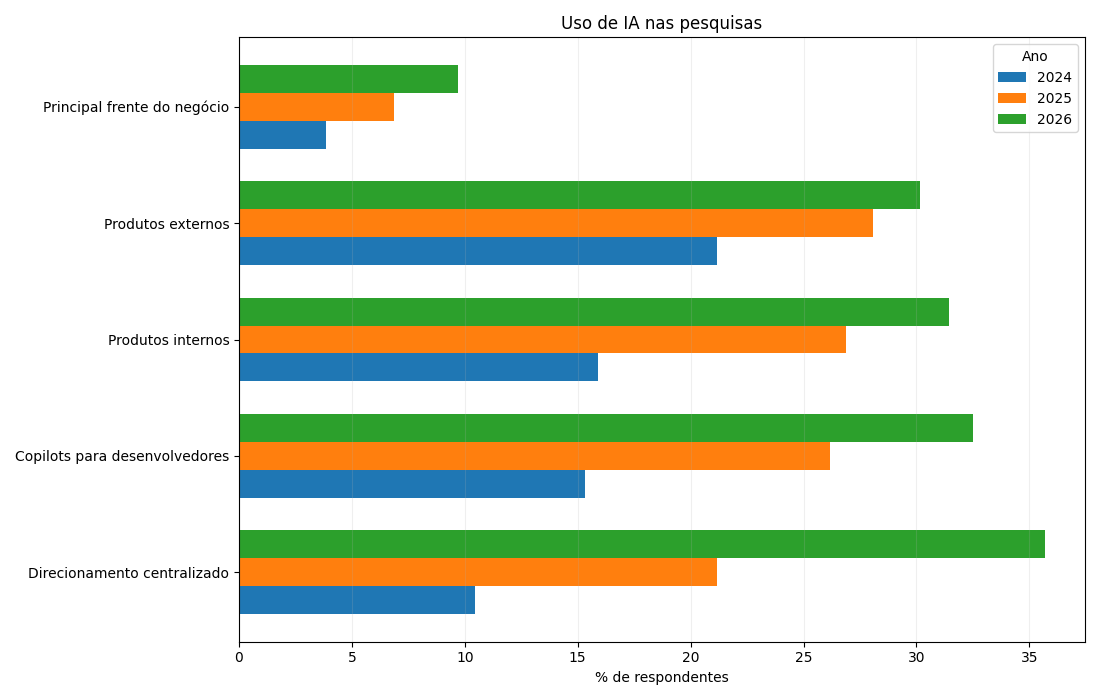

In [73]:
df_grafico = ia_adocao.toPandas()

df_grafico["ano"] = df_grafico["ano_pesquisa"].map({
    "2023_2024": "2024",
    "2024_2025": "2025",
    "2025_2026": "2026"
})

indicadores = [
    "ia_direcionamento_centralizado",
    "desenvolvedores_copilots",
    "ia_produtos_internos",
    "ia_produtos_externos",
    "ia_principal_frente_negocio"
]

nomes = {
    "ia_direcionamento_centralizado": "Direcionamento centralizado",
    "desenvolvedores_copilots": "Copilots para desenvolvedores",
    "ia_produtos_internos": "Produtos internos",
    "ia_produtos_externos": "Produtos externos",
    "ia_principal_frente_negocio": "Principal frente do negócio"
}

df_grafico = df_grafico[
    df_grafico["indicador"].isin(indicadores)
].copy()

df_grafico["indicador_nome"] = df_grafico["indicador"].map(nomes)

ordem_indicadores = [
    "Direcionamento centralizado",
    "Copilots para desenvolvedores",
    "Produtos internos",
    "Produtos externos",
    "Principal frente do negócio"
]

pivot = (
    df_grafico
    .pivot(
        index="indicador_nome",
        columns="ano",
        values="percentual"
    )
    .reindex(ordem_indicadores)
    .reindex(columns=["2024", "2025", "2026"])
)

y = np.arange(len(ordem_indicadores))
largura = 0.24

plt.figure(figsize=(11, 7))

plt.barh(
    y - largura,
    pivot["2024"],
    height=largura,
    label="2024"
)

plt.barh(
    y,
    pivot["2025"],
    height=largura,
    label="2025"
)

plt.barh(
    y + largura,
    pivot["2026"],
    height=largura,
    label="2026"
)

plt.yticks(y, ordem_indicadores)
plt.xlabel("% de respondentes")

plt.title(
    "Uso de IA nas pesquisas"
)

plt.legend(title="Ano")

plt.grid(axis="x", alpha=0.2)

plt.tight_layout()

%matplot plt

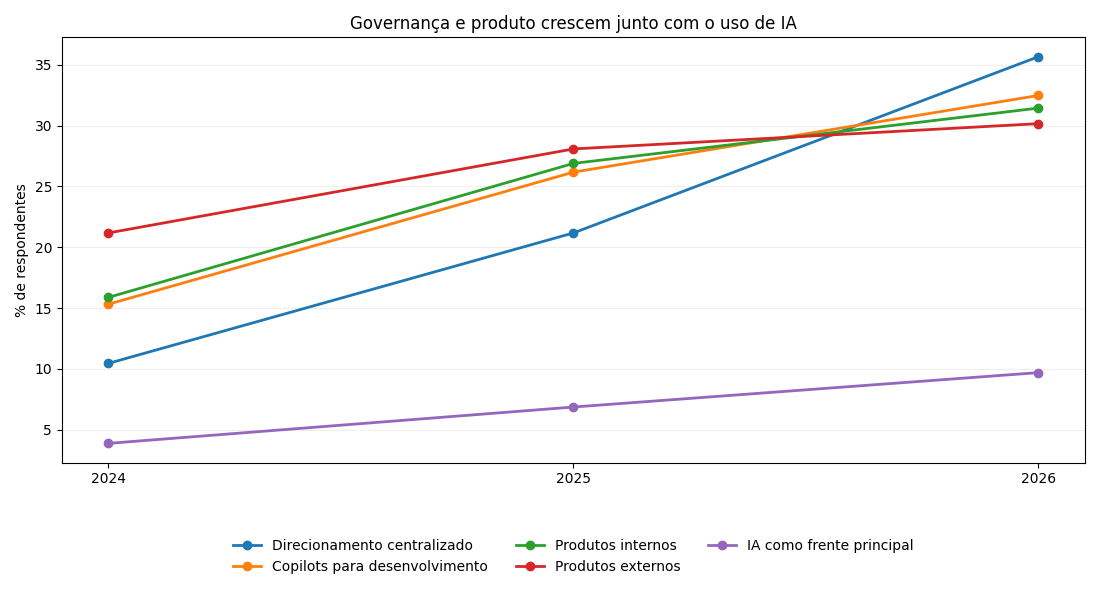

In [75]:
df_grafico = ia_adocao.toPandas()

df_grafico["ano"] = df_grafico["ano_pesquisa"].map({
    "2023_2024": "2024",
    "2024_2025": "2025",
    "2025_2026": "2026"
})

indicadores = [
    "ia_direcionamento_centralizado",
    "desenvolvedores_copilots",
    "ia_produtos_internos",
    "ia_produtos_externos",
    "ia_principal_frente_negocio"
]

nomes = {
    "ia_direcionamento_centralizado": "Direcionamento centralizado",
    "desenvolvedores_copilots": "Copilots para desenvolvimento",
    "ia_produtos_internos": "Produtos internos",
    "ia_produtos_externos": "Produtos externos",
    "ia_principal_frente_negocio": "IA como frente principal"
}

df_grafico = df_grafico[
    df_grafico["indicador"].isin(indicadores)
].copy()

df_grafico["indicador_nome"] = df_grafico["indicador"].map(nomes)

pivot = (
    df_grafico
    .pivot(
        index="ano",
        columns="indicador_nome",
        values="percentual"
    )
    .reindex(["2024", "2025", "2026"])
)

plt.figure(figsize=(11, 6))

for indicador in nomes.values():
    plt.plot(
        pivot.index,
        pivot[indicador],
        marker="o",
        linewidth=2,
        label=indicador
    )

plt.xlabel("")
plt.ylabel("% de respondentes")

plt.title(
    "Governança e produto crescem junto com o uso de IA"
)

plt.grid(axis="y", alpha=0.2)

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=3,
    frameon=False
)

plt.tight_layout()

%matplot plt

In [131]:
ia_indice = (
    ia
    .withColumn(
        "nivel_maturidade_ia",
        F.when(
            F.col("ia_principal_frente_negocio") == "1",
            "3 - Adoção estratégica"
        )
        .when(
            (F.col("ia_direcionamento_centralizado") == "1") |
            (F.col("desenvolvedores_copilots") == "1") |
            (F.col("ia_produtos_externos") == "1") |
            (F.col("ia_produtos_internos") == "1"),
            "2 - Adoção estruturada"
        )
        .when(
            F.col("ia_independente_descentralizada") == "1",
            "1 - Experimentação"
        )
        .when(
            (F.col("ia_nao_prioridade") == "1") |
            (F.col("nao_sabe_uso_ia") == "1"),
            "0 - Sem adoção identificada"
        )
        .otherwise(None)
    )
)

In [132]:
ia_maturidade = (
    ia_indice
    .filter(F.col("nivel_maturidade_ia").isNotNull())
    .groupBy(
        "ano_pesquisa",
        "nivel_maturidade_ia"
    )
    .count()
    .withColumnRenamed("count", "qtd_profissionais")
)

total_ia_maturidade = (
    ia_maturidade
    .groupBy("ano_pesquisa")
    .agg(
        F.sum("qtd_profissionais").alias("total_respostas")
    )
)

ia_maturidade = (
    ia_maturidade
    .join(
        total_ia_maturidade,
        on="ano_pesquisa",
        how="left"
    )
    .withColumn(
        "percentual",
        F.round(
            (F.col("qtd_profissionais") / F.col("total_respostas")) * 100,
            2
        )
    )
    .orderBy(
        "ano_pesquisa",
        "nivel_maturidade_ia"
    )
)

ia_maturidade.show()

+------------+--------------------+-----------------+---------------+----------+
|ano_pesquisa| nivel_maturidade_ia|qtd_profissionais|total_respostas|percentual|
+------------+--------------------+-----------------+---------------+----------+
|   2023_2024|0 - Sem adoção id...|             1116|           3772|     29.59|
|   2023_2024|  1 - Experimentação|             1110|           3772|     29.43|
|   2023_2024|2 - Adoção estrut...|             1400|           3772|     37.12|
|   2023_2024|3 - Adoção estrat...|              146|           3772|      3.87|
|   2024_2025|0 - Sem adoção id...|              548|           3617|     15.15|
|   2024_2025|  1 - Experimentação|              966|           3617|     26.71|
|   2024_2025|2 - Adoção estrut...|             1855|           3617|     51.29|
|   2024_2025|3 - Adoção estrat...|              248|           3617|      6.86|
|   2025_2026|0 - Sem adoção id...|              162|           2105|       7.7|
|   2025_2026|  1 - Experime

In [133]:
impacto_ia = (
    ia_adocao
    .filter(
        F.col("indicador").isin(
            "ia_produtos_externos",
            "ia_produtos_internos",
            "desenvolvedores_copilots",
            "ia_principal_frente_negocio"
        )
    )
    .select(
        "ano_pesquisa",
        "indicador",
        "percentual"
    )
)

impacto_ia.show()

+------------+--------------------+----------+
|ano_pesquisa|           indicador|percentual|
+------------+--------------------+----------+
|   2023_2024|ia_produtos_externos|     21.18|
|   2023_2024|ia_produtos_internos|     15.88|
|   2023_2024|desenvolvedores_c...|     15.32|
|   2023_2024|ia_principal_fren...|      3.87|
|   2024_2025|ia_produtos_externos|     28.09|
|   2024_2025|ia_produtos_internos|      26.9|
|   2024_2025|desenvolvedores_c...|     26.18|
|   2024_2025|ia_principal_fren...|      6.86|
|   2025_2026|desenvolvedores_c...|     32.49|
|   2025_2026|ia_produtos_internos|     31.45|
|   2025_2026|ia_produtos_externos|     30.17|
|   2025_2026|ia_principal_fren...|      9.69|
+------------+--------------------+----------+


In [134]:
regiao_senioridade = (
    perfil_analise
    .filter(
        F.col("regiao").isNotNull() &
        F.col("nivel").isNotNull()
    )
    .groupBy(
        "ano_pesquisa",
        "regiao",
        "nivel"
    )
    .agg(
        F.count("*").alias("qtd_profissionais")
    )
)

In [135]:
window_regiao = Window.partitionBy(
    "ano_pesquisa",
    "regiao"
)

regiao_senioridade = (
    regiao_senioridade
    .withColumn(
        "total_regiao",
        F.sum("qtd_profissionais").over(window_regiao)
    )
    .withColumn(
        "percentual",
        F.round(
            (F.col("qtd_profissionais") / F.col("total_regiao")) * 100,
            2
        )
    )
    .orderBy(
        "ano_pesquisa",
        "regiao",
        F.desc("percentual")
    )
)

regiao_senioridade.show(100, truncate=False)

+------------+------------+-------------------+-----------------+------------+----------+
|ano_pesquisa|regiao      |nivel              |qtd_profissionais|total_regiao|percentual|
+------------+------------+-------------------+-----------------+------------+----------+
|2023_2024   |Centro-oeste|Sênior             |91               |247         |36.84     |
|2023_2024   |Centro-oeste|Pleno              |80               |247         |32.39     |
|2023_2024   |Centro-oeste|Júnior             |76               |247         |30.77     |
|2023_2024   |Nordeste    |Pleno              |168              |430         |39.07     |
|2023_2024   |Nordeste    |Júnior             |141              |430         |32.79     |
|2023_2024   |Nordeste    |Sênior             |121              |430         |28.14     |
|2023_2024   |Norte       |Pleno              |27               |58          |46.55     |
|2023_2024   |Norte       |Júnior             |21               |58          |36.21     |
|2023_2024

In [136]:
perfil_analise = (
    perfil_analise
    .withColumn(
        "ordem_salarial",
        F.when(F.col("faixa_salarial") == "Menos de R$ 1.000/mês", 1)
        .when(F.col("faixa_salarial") == "de R$ 1.001/mês a R$ 2.000/mês", 2)
        .when(F.col("faixa_salarial") == "de R$ 2.001/mês a R$ 3.000/mês", 3)
        .when(F.col("faixa_salarial") == "de R$ 3.001/mês a R$ 4.000/mês", 4)
        .when(F.col("faixa_salarial") == "de R$ 4.001/mês a R$ 6.000/mês", 5)
        .when(F.col("faixa_salarial") == "de R$ 6.001/mês a R$ 8.000/mês", 6)
        .when(F.col("faixa_salarial") == "de R$ 8.001/mês a R$ 12.000/mês", 7)
        .when(F.col("faixa_salarial") == "de R$ 12.001/mês a R$ 16.000/mês", 8)
        .when(F.col("faixa_salarial") == "de R$ 16.001/mês a R$ 20.000/mês", 9)
        .when(F.col("faixa_salarial") == "de R$ 20.001/mês a R$ 25.000/mês", 10)
        .when(F.col("faixa_salarial") == "de R$ 25.001/mês a R$ 30.000/mês", 11)
        .when(F.col("faixa_salarial") == "de R$ 30.001/mês a R$ 40.000/mês", 12)
        .when(F.col("faixa_salarial") == "Acima de R$ 40.001/mês", 13)
    )
)

In [137]:
regiao_remuneracao = (
    perfil_analise
    .filter(
        F.col("regiao").isNotNull() &
        F.col("faixa_salarial").isNotNull() &
        F.col("ordem_salarial").isNotNull()
    )
    .withColumn(
        "grupo_salarial",
        F.when(F.col("ordem_salarial") <= 4, "Até R$ 4 mil")
        .when(F.col("ordem_salarial") <= 7, "R$ 4.001 a R$ 12 mil")
        .otherwise("Acima de R$ 12 mil")
    )
    .groupBy(
        "ano_pesquisa",
        "regiao",
        "grupo_salarial"
    )
    .agg(
        F.count("*").alias("qtd_profissionais")
    )
)

In [138]:
window_regiao = Window.partitionBy(
    "ano_pesquisa",
    "regiao"
)

regiao_remuneracao = (
    regiao_remuneracao
    .withColumn(
        "total_regiao",
        F.sum("qtd_profissionais").over(window_regiao)
    )
    .withColumn(
        "percentual",
        F.round(
            (F.col("qtd_profissionais") / F.col("total_regiao")) * 100,
            2
        )
    )
    .orderBy(
        "ano_pesquisa",
        "regiao",
        "grupo_salarial"
    )
)

regiao_remuneracao.show(100, truncate=False)

+------------+------------+--------------------+-----------------+------------+----------+
|ano_pesquisa|regiao      |grupo_salarial      |qtd_profissionais|total_regiao|percentual|
+------------+------------+--------------------+-----------------+------------+----------+
|2023_2024   |Centro-oeste|Acima de R$ 12 mil  |95               |304         |31.25     |
|2023_2024   |Centro-oeste|Até R$ 4 mil        |59               |304         |19.41     |
|2023_2024   |Centro-oeste|R$ 4.001 a R$ 12 mil|150              |304         |49.34     |
|2023_2024   |Nordeste    |Acima de R$ 12 mil  |100              |501         |19.96     |
|2023_2024   |Nordeste    |Até R$ 4 mil        |146              |501         |29.14     |
|2023_2024   |Nordeste    |R$ 4.001 a R$ 12 mil|255              |501         |50.9      |
|2023_2024   |Norte       |Acima de R$ 12 mil  |8                |69          |11.59     |
|2023_2024   |Norte       |Até R$ 4 mil        |18               |69          |26.09     |

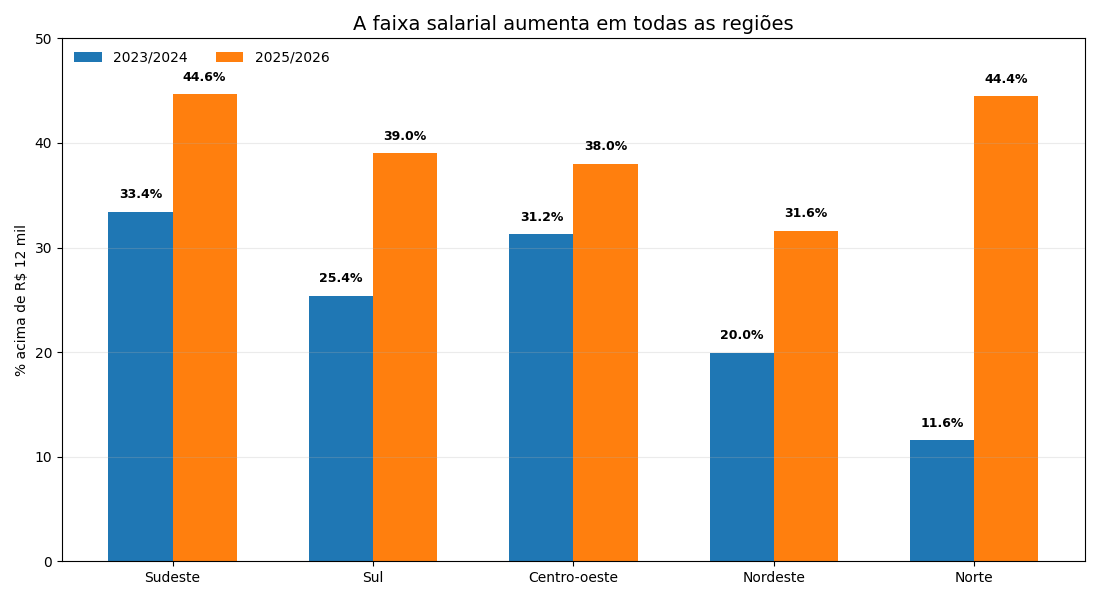

In [140]:
df_grafico = regiao_remuneracao.toPandas()

df_grafico = df_grafico[
    df_grafico["grupo_salarial"] == "Acima de R$ 12 mil"
].copy()

df_grafico = df_grafico[
    df_grafico["ano_pesquisa"].isin(
        ["2023_2024", "2025_2026"]
    )
].copy()

regioes = [
    "Sudeste",
    "Sul",
    "Centro-oeste",
    "Nordeste",
    "Norte"
]

tabela = df_grafico.pivot(
    index="regiao",
    columns="ano_pesquisa",
    values="percentual"
)

tabela = tabela.reindex(regioes)

x = np.arange(len(regioes))
largura = 0.32

plt.figure(figsize=(11, 6))

anos = ["2023_2024", "2025_2026"]

for i, ano in enumerate(anos):

    valores = tabela[ano].values

    posicao = x + (i - 0.5) * largura

    barras = plt.bar(
        posicao,
        valores,
        width=largura,
        label=ano.replace("_", "/")
    )

    for barra, valor in zip(barras, valores):

        plt.text(
            barra.get_x() + barra.get_width() / 2,
            valor + 1,
            f"{valor:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold"
        )

plt.xticks(
    x,
    regioes
)

plt.ylabel("% acima de R$ 12 mil")
plt.xlabel("")

plt.title(
    "A faixa salarial aumenta em todas as regiões",
    fontsize=14
)

plt.ylim(0, 50)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.legend(
    loc="upper left",
    frameon=False,
    ncol=2
)

plt.tight_layout()

%matplot plt

In [10]:
genero_mercado.show(10, False)
raca_mercado.show(10, False)
pcd_mercado.show(10, False)

session_id=66bcec70-49f0-4ceb-8c41-c17cffa4b095 has reached TIMEOUT status. 
Please re-run the same cell to restart the session. You may also need to re-run previous cells if trying to use pre-defined variables.


In [78]:
modelo_atual = (
    perfil_analise
    .filter(
    F.col("forma_trabalho").isNotNull() &
    (F.col("forma_trabalho") != "0")
)
    .groupBy(
        "ano_pesquisa",
        "forma_trabalho"
    )
    .agg(
        F.count("*").alias("qtd_profissionais")
    )
)

window_ano = Window.partitionBy("ano_pesquisa")

modelo_atual = (
    modelo_atual
    .withColumn(
        "total_respostas",
        F.sum("qtd_profissionais").over(window_ano)
    )
    .withColumn(
        "percentual",
        F.round(
            (F.col("qtd_profissionais") / F.col("total_respostas")) * 100,
            2
        )
    )
    .orderBy(
        "ano_pesquisa",
        F.desc("percentual")
    )
)

modelo_atual.show(50, truncate=False)

+------------+--------------------------------------------------------------------------------------------------------------+-----------------+---------------+----------+
|ano_pesquisa|forma_trabalho                                                                                                |qtd_profissionais|total_respostas|percentual|
+------------+--------------------------------------------------------------------------------------------------------------+-----------------+---------------+----------+
|2023_2024   |Modelo 100% remoto                                                                                            |2201             |4753           |46.31     |
|2023_2024   |Modelo híbrido flexível (o funcionário tem liberdade para escolher quando estar no escritório presencialmente)|972              |4753           |20.45     |
|2023_2024   |Modelo híbrido com dias fixos de trabalho presencial                                                          |790              |47

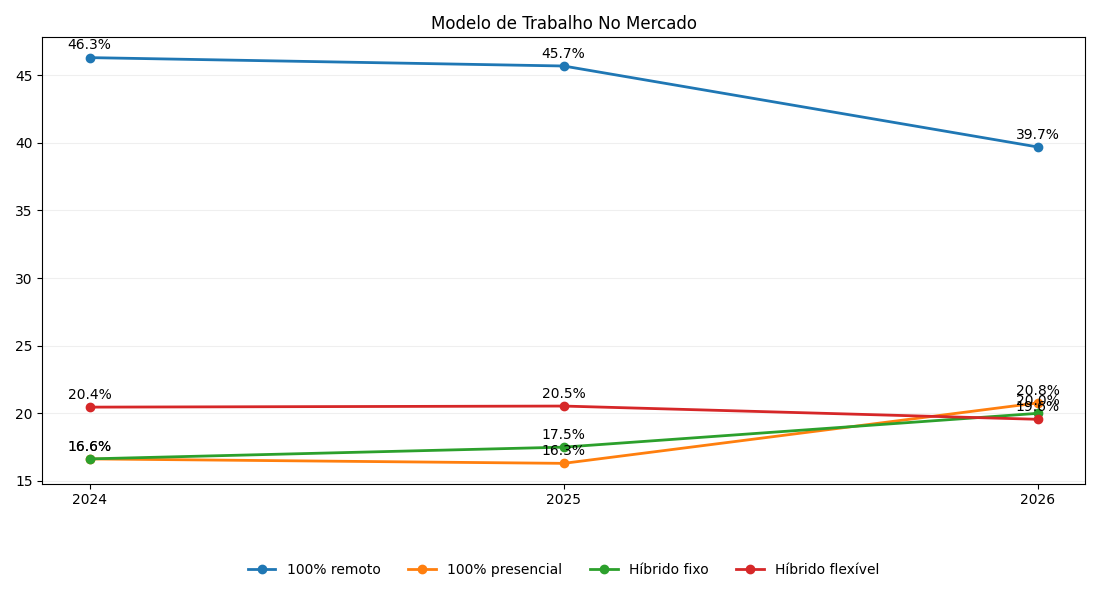

In [80]:
df_grafico = modelo_atual.toPandas()

df_grafico["ano"] = df_grafico["ano_pesquisa"].map({
    "2023_2024": "2024",
    "2024_2025": "2025",
    "2025_2026": "2026"
})

nomes = {
    "Modelo 100% remoto": "100% remoto",
    "Modelo 100% presencial": "100% presencial",
    "Modelo híbrido com dias fixos de trabalho presencial": "Híbrido fixo",
    "Modelo híbrido flexível (o funcionário tem liberdade para escolher quando estar no escritório presencialmente)": "Híbrido flexível"
}

df_grafico["modelo"] = df_grafico["forma_trabalho"].map(nomes)

pivot = (
    df_grafico
    .pivot(
        index="ano",
        columns="modelo",
        values="percentual"
    )
    .reindex(["2024", "2025", "2026"])
)

ordem_modelos = [
    "100% remoto",
    "100% presencial",
    "Híbrido fixo",
    "Híbrido flexível"
]

plt.figure(figsize=(11, 6))

for modelo in ordem_modelos:
    plt.plot(
        pivot.index,
        pivot[modelo],
        marker="o",
        linewidth=2,
        label=modelo
    )

for modelo in ordem_modelos:
    for ano in pivot.index:
        valor = pivot.loc[ano, modelo]

        plt.annotate(
            f"{valor:.1f}%",
            (ano, valor),
            textcoords="offset points",
            xytext=(0, 6),
            ha="center"
        )

plt.xlabel("")

plt.title(
    "Modelo de Trabalho No Mercado"
)

plt.grid(axis="y", alpha=0.2)

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=4,
    frameon=False
)

plt.tight_layout()

%matplot plt

In [81]:
modelo_x_retorno = (
    perfil
    .filter(
        F.col("forma_trabalho").isNotNull() &
        F.col("retorno_presencial").isNotNull()
    )
    .filter(
        F.col("forma_trabalho") != "0"
    )
    .groupBy(
        "ano_pesquisa",
        "forma_trabalho",
        "retorno_presencial"
    )
    .agg(
        F.count("*").alias("qtd_profissionais")
    )
)

window_modelo = Window.partitionBy(
    "ano_pesquisa",
    "forma_trabalho"
)

modelo_x_retorno = (
    modelo_x_retorno
    .withColumn(
        "total_modelo",
        F.sum("qtd_profissionais").over(window_modelo)
    )
    .withColumn(
        "percentual",
        F.round(
            (F.col("qtd_profissionais") / F.col("total_modelo")) * 100,
            2
        )
    )
    .orderBy(
        "ano_pesquisa",
        "forma_trabalho",
        F.desc("percentual")
    )
)

modelo_x_retorno.show(100, truncate=False)

+------------+--------------------------------------------------------------------------------------------------------------+-----------------------------------------------------------+-----------------+------------+----------+
|ano_pesquisa|forma_trabalho                                                                                                |retorno_presencial                                         |qtd_profissionais|total_modelo|percentual|
+------------+--------------------------------------------------------------------------------------------------------------+-----------------------------------------------------------+-----------------+------------+----------+
|2023_2024   |Modelo 100% presencial                                                                                        |Vou aceitar e retornar ao modelo 100% presencial           |522              |790         |66.08     |
|2023_2024   |Modelo 100% presencial                                                    

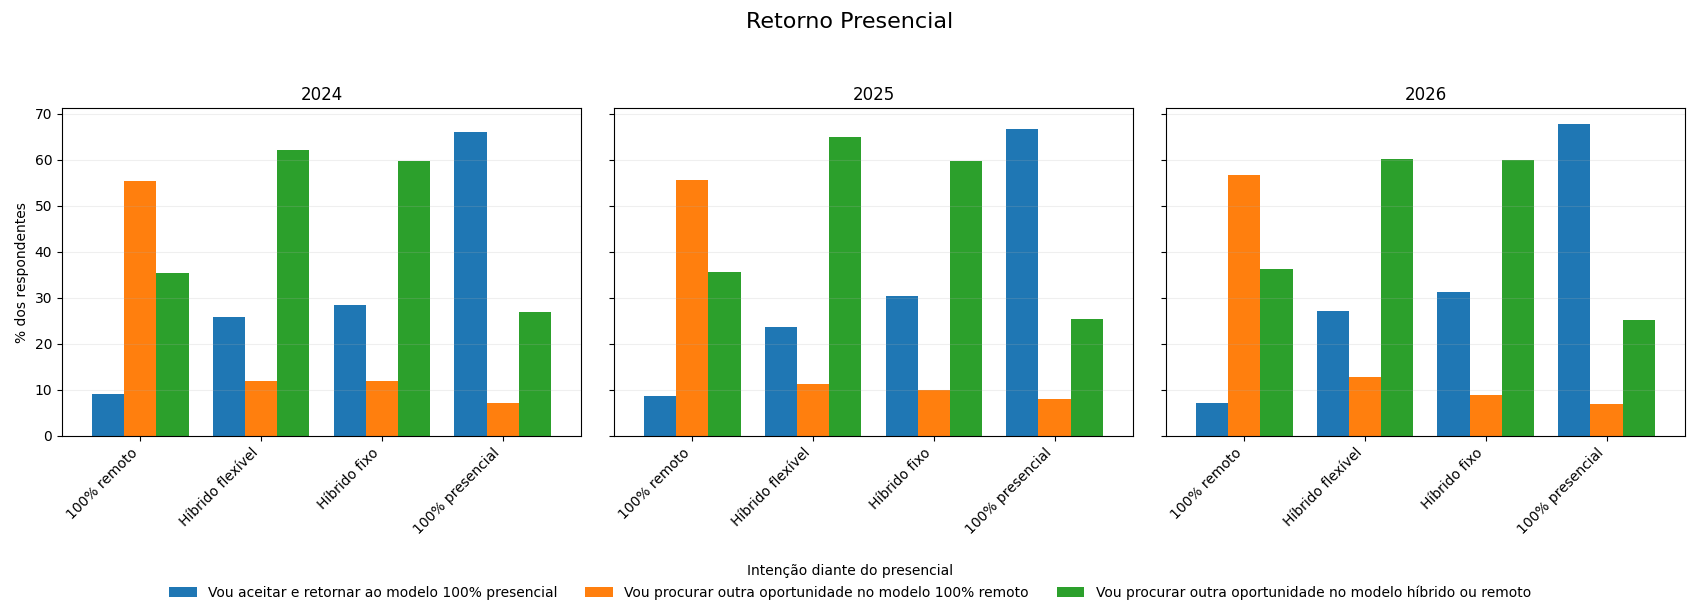

In [89]:
df_grafico = modelo_x_retorno.toPandas()

df_grafico["ano"] = df_grafico["ano_pesquisa"].map({
    "2023_2024": "2024",
    "2024_2025": "2025",
    "2025_2026": "2026"
})

nomes_modelos = {
    "Modelo 100% remoto": "100% remoto",
    "Modelo 100% presencial": "100% presencial",
    "Modelo híbrido com dias fixos de trabalho presencial": "Híbrido fixo",
    "Modelo híbrido flexível (o funcionário tem liberdade para escolher quando estar no escritório presencialmente)": "Híbrido flexível"
}

df_grafico["modelo"] = df_grafico["forma_trabalho"].map(nomes_modelos)

df_grafico = (
    df_grafico
    .groupby(
        ["ano", "modelo", "retorno_presencial"],
        as_index=False
    )["percentual"]
    .sum()
)

ordem_modelos = [
    "100% remoto",
    "Híbrido flexível",
    "Híbrido fixo",
    "100% presencial"
]

ordem_intencoes = sorted(
    df_grafico["retorno_presencial"].dropna().unique()
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 6),
    sharey=True
)

anos = ["2024", "2025", "2026"]

for ax, ano in zip(axes, anos):

    df_ano = df_grafico[
        df_grafico["ano"] == ano
    ]

    tabela = (
        df_ano
        .pivot(
            index="modelo",
            columns="retorno_presencial",
            values="percentual"
        )
        .reindex(ordem_modelos)
    )

    tabela.plot(
        kind="bar",
        ax=ax,
        width=0.8
    )

    ax.set_title(ano)
    ax.set_xlabel("")
    ax.set_xticklabels(
        ordem_modelos,
        rotation=45,
        ha="right"
    )

    ax.grid(axis="y", alpha=0.2)

    if ano == "2024":
        ax.set_ylabel("% dos respondentes")
    else:
        ax.set_ylabel("")

    ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Intenção diante do presencial",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    frameon=False
)

fig.suptitle(
    "Retorno Presencial",
    fontsize=16
)

plt.tight_layout(rect=[0, 0.08, 1, 0.94])

%matplot plt

# Exportação das bases

In [231]:
df_silver_2023_24.write.mode("overwrite").parquet(
    "s3://lab-802081848218/data-output/2023-2024/Silver/"
)

df_silver_2024_25.write.mode("overwrite").parquet(
    "s3://lab-802081848218/data-output/2024-2025/Silver/"
)

df_silver_2025_26.write.mode("overwrite").parquet(
    "s3://lab-802081848218/data-output/2025-2026/Silver/"
)

In [236]:
perfil.write.mode("overwrite").parquet(
    "s3://lab-802081848218/data-output/Gold/perfil/"
)

tecnologias.write.mode("overwrite").parquet(
    "s3://lab-802081848218/data-output/Gold/tecnologias/"
)

ia.write.mode("overwrite").parquet(
    "s3://lab-802081848218/data-output/Gold/ia/"
)

In [237]:
perfil.coalesce(1).write.mode("overwrite").option("header", True).csv(
    "s3://lab-802081848218/data-output/Gold/perfil_csv/"
)

tecnologias.coalesce(1).write.mode("overwrite").option("header", True).csv(
    "s3://lab-802081848218/data-output/Gold/tecnologias_csv/"
)

ia.coalesce(1).write.mode("overwrite").option("header", True).csv(
    "s3://lab-802081848218/data-output/Gold/ia_csv/"
)